# ZShooter Science Validation

This notebook is the release-facing validation path for the ZShooter ScopeSim model. It is meant to answer science and instrument-engineering questions directly: what is configured, what physical effects are included, what the dominant rates are, whether simple back-of-the-envelope scales agree, and what changes when common background/AO/source knobs are toggled.

The older `zshooter_validation.ipynb` remains useful as a developer lab notebook. This notebook intentionally keeps the important knobs close to the calculations they control, and it leaves the code visible so a scientist can rerun the same reasoning with different source, slit, seeing, airmass, or background settings.

In [1]:
%matplotlib inline
from collections import OrderedDict
from contextlib import contextmanager
from math import erf
import logging
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.table import Table

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp


In [2]:
from zs_scopesim_tools.helpers import configure_path_and_logging, disable_scopesim_progress_bars, disable_scopesim_top_level_catch, validation_work_dir, warning_prevent_sync_alt_ra_dec, zshooter_package_dir, ignore_warnings
from zs_scopesim_tools.sources import angle_from_cmds, constant_photon_flux_flat, field_angle_demo_sources, lamp_flat
from zs_scopesim_tools.plots import plot_detector_background_budget, plot_detector_image_grid, plot_emissivity_sanity, plot_post_disperser_diffuse_background, plot_readout_cross_dispersion_cut, plot_readout_overview, plot_slit_adc_psf_scenes, plot_slit_loss_by_arm, plot_slit_width_loss, plot_source, plot_trace_resolving_power_detector_maps, plot_transmission_sanity, show_and_save_hdul
from zs_scopesim_tools.validation import build_emissivity_sanity_data, build_post_disperser_diffuse_background_data, build_slit_adc_psf_scene_data, build_slit_loss_data, build_slit_width_loss_data, build_transmission_sanity_data, detector_background_budget_table, detector_geometry_table, detector_qe_accounting_table, detector_selector_matrix, effect_name, fetch_effect_spectrum_or_transmission, fov_image_plane_counts, get_effect, post_disperser_diffuse_effect_consistency_table, readout_delta_summary_table, science_truth_crosscheck_table, slit_adc_psf_status_table, slit_pair_status_table, source_position_table, trace_catalog_table, trace_resolution_diagnostic_table, trace_resolution_summary_display_table, trace_resolution_summary_table, validate_emissivity_sanity_data, validate_post_disperser_diffuse_background_data, validate_post_disperser_diffuse_effect_consistency, validate_transmission_sanity_data
ignore_warnings()

## Run Configuration

Edit this cell first. The notebook is organized so the configuration, source construction, and background toggles are near the calculations that depend on them. The altitude is derived from the requested airmass and RA/Dec are cleared so sky and PSF terms are driven by the quantities that matter for this simulator validation: airmass, seeing, sky brightness, slit, exposure time, and enabled effects.

In [3]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="warning")
zshooter_dir = zshooter_package_dir(irdb_path)
output_dir = validation_work_dir(irdb_path, name="science_validation_outputs")
hide_scopesim_progress = True
disable_scopesim_top_level_catch()

from skycalc_ipy.core import SkyModel, get_cache_dir
SkyModel.REQUEST_TIMEOUT = 60
# print(f"SkyCalc timeout: {SkyModel.REQUEST_TIMEOUT}s; cache: {get_cache_dir()}")

cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

def set_channel_exposure(cmds, *, dit, ndit):
    cmds["!OBS.dit"] = dit
    cmds["!OBS.ndit"] = ndit
    for channel in ("blue", "green", "red", "yj", "h", "k"):
        cmds[f"!OBS.dit_{channel}"] = dit
        cmds[f"!OBS.ndit_{channel}"] = ndit

validation_brightness = "grey"
cmd["!OBS.airmass"] = 1.1
cmd["!OBS.seeing"] = 0.65
cmd["!OBS.brightness"] = validation_brightness
cmd["!OBS.pupil_angle"] = 0.0
set_channel_exposure(cmd, dit=1800, ndit=2)
cmd["!INST.vis_curr_slit"] = 0.7 # 0.33
cmd["!INST.nir_curr_slit"] = 0.7 # 0.33
# ZShooter_v2 currently keeps spectral resolution as this explicit scalar; update it with the slit if testing a slit-dependent resolution assumption.
cmd["!INST.include_diffuse_emmisivity"] = False
warning_prevent_sync_alt_ra_dec(cmd)

component_metadata = {"telescope_reflection": {"throughput_group": "telescope", "emission_phase": "pre_disperser"},
                      "ir_blocking_filter_selector": {"throughput_group": "ir_blocking_filter"},
                      }

zs = sim.OpticalTrain(cmd)
print(f"Validation outputs: {output_dir}")

astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - WARNING: Obstime is not after sunset!
py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:170: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

Validation outputs: 

In [4]:
def cmd_value(key):
    try:
        return from_currsys(key, cmd)
    except Exception:
        return None

def train_cmd_value(key):
    try:
        return from_currsys(key, zs.cmds)
    except Exception:
        return None


def display_frame(data, *, columns=None, rename=None, formats=None):
    if isinstance(data, Table):
        view = data[columns] if columns is not None else data
        frame = view.to_pandas()
    else:
        frame = pd.DataFrame(data)
        if columns is not None:
            frame = frame.loc[:, columns]
    if rename:
        frame = frame.rename(columns=rename)
    styler = frame.style.hide(axis="index")
    if formats:
        active_formats = {key: value for key, value in formats.items() if key in frame.columns}
        styler = styler.format(active_formats, na_rep="--")
    display(styler)


def compact_range(minimum, maximum, digits=1):
    if not np.isfinite(minimum) or not np.isfinite(maximum):
        return "--"
    if np.isclose(minimum, maximum, rtol=1e-4, atol=10**-digits):
        return f"{minimum:.{digits}f}"
    return f"{minimum:.{digits}f}-{maximum:.{digits}f}"

run_card = Table(rows=[
    {"quantity": "instrument", "value": "ZShooter_v2 SPEC", "why_it_matters": "loads the release IRDB model"},
    {"quantity": "airmass", "value": cmd_value("!OBS.airmass"), "why_it_matters": "sets atmospheric path, dispersion, and sky"},
    {"quantity": "altitude [deg]", "value": cmd_value("!OBS.alt"), "why_it_matters": "derived from airmass for ScopeSim AltAz context"},
    {"quantity": "RA/Dec", "value": f"{cmd_value('!OBS.ra')}/{cmd_value('!OBS.dec')}", "why_it_matters": "cleared so they do not override airmass"},
    {"quantity": "seeing [arcsec]", "value": cmd_value("!OBS.seeing"), "why_it_matters": "natural-seeing PSF scale"},
    {"quantity": "sky brightness", "value": cmd_value("!OBS.brightness"), "why_it_matters": "SkyCalc continuum/line brightness preset"},
    {"quantity": "command telescope area", "value": cmd_value("!TEL.area"), "why_it_matters": "pre-train default; should be replaced by optical-train derived area"},
    {"quantity": "train telescope area", "value": train_cmd_value("!TEL.area"), "why_it_matters": "derived from the active Keck mirror SurfaceList and used by FOV/source scaling"},
    {"quantity": "VIS slit [arcsec]", "value": cmd_value("!INST.vis_curr_slit"), "why_it_matters": "source throughput and resolution"},
    {"quantity": "NIR slit [arcsec]", "value": cmd_value("!INST.nir_curr_slit"), "why_it_matters": "source throughput and resolution"},
    {"quantity": "spectral resolving power guardrail", "value": cmd_value("!SIM.spectral.spectral_resolution"), "why_it_matters": "internal spectral work grid / sky sampling guardrail"},
    {"quantity": "DIT x NDIT", "value": f"{cmd_value('!OBS.dit_green')} x {cmd_value('!OBS.ndit_green')}", "why_it_matters": "per-channel detector exposure; total is DIT*NDIT"},
    {"quantity": "pupil angle [deg]", "value": cmd_value("!OBS.pupil_angle"), "why_it_matters": "source-pair orientation used below"},
])
display_frame(run_card, rename={"why_it_matters": "why it matters"})

# print("Trace catalog")
# trace_catalog = trace_catalog_table(get_effect(zs, "trace_list_analytical"))
# display_frame(
#     trace_catalog,
#     columns=["trace_id", "aperture_id", "image_plane_id", "wave_min_um", "wave_max_um"],
#     rename={
#         "trace_id": "trace",
#         "aperture_id": "aperture id",
#         "image_plane_id": "image plane id",
#         "wave_min_um": "wave min [um]",
#         "wave_max_um": "wave max [um]",
#     },
#     formats={"wave min [um]": "{:.4f}", "wave max [um]": "{:.4f}"},
# )
print("FoV image-plane counts")
display_frame(fov_image_plane_counts(zs), rename={"image_plane_id": "image plane id", "n_fovs": "FoVs"})


quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
airmass,1.100000,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.380023,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.650000,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
command telescope area,0,pre-train default; should be replaced by optical-train derived area
train telescope area,76.52965998654079 m2,derived from the active Keck mirror SurfaceList and used by FOV/source scaling
VIS slit [arcsec],0.700000,source throughput and resolution
NIR slit [arcsec],0.700000,source throughput and resolution


FoV image-plane counts


image plane id,FoVs
0,35
1,31
2,21
3,24
4,12
5,7


## Trace Geometry And Resolution Scale

This detector-facing diagnostic samples the loaded spectral traces on the active image planes. The table gives compact channel ranges; the first map shows local resolving power from the trace geometry and detector pixel scale, while the second map shows the corresponding spectral-element sampling width. Blank pixels are off trace. The plotted samples are kept only where the sampled slit footprint is fully on detector; the trace catalog below is the check for the total loaded order count. Detector rotation is part of the trace geometry being checked; `detector_pad` is legacy metadata and is not applied to the optical trace geometry.

,ch,id,orders,wave nm,slit,disp nm/pix,R k,nyq R k,pix/resel,seeing
0,B,0,35,306-437,"0.70""",0.0032-0.0063,15.1-21.9,33.7-48.8,17.6-24.0,"0.73""/4.7 pix"
1,G,1,30,425-656,"0.70""",0.0046-0.0094,15.3-21.6,34.0-48.3,16.6-22.3,"0.68""/4.4 pix"
2,R,2,21,644-1021,"0.70""",0.0068-0.0146,15.2-21.6,34.0-48.2,15.3-20.5,"0.63""/4.0 pix"
3,YJ,3,23,949-1346,"0.70""",0.0106-0.0189,15.5-20.9,34.7-46.7,14.0-19.3,"0.59""/3.8 pix"
4,H,4,11,1471-1871,"0.70""",0.0164-0.0264,15.5-21.1,34.6-47.0,13.1-17.5,"0.54""/3.5 pix"
5,K,5,7,2027-2474,"0.70""",0.0221-0.0349,15.5-21.1,34.6-47.0,12.5-16.5,"0.51""/3.3 pix"


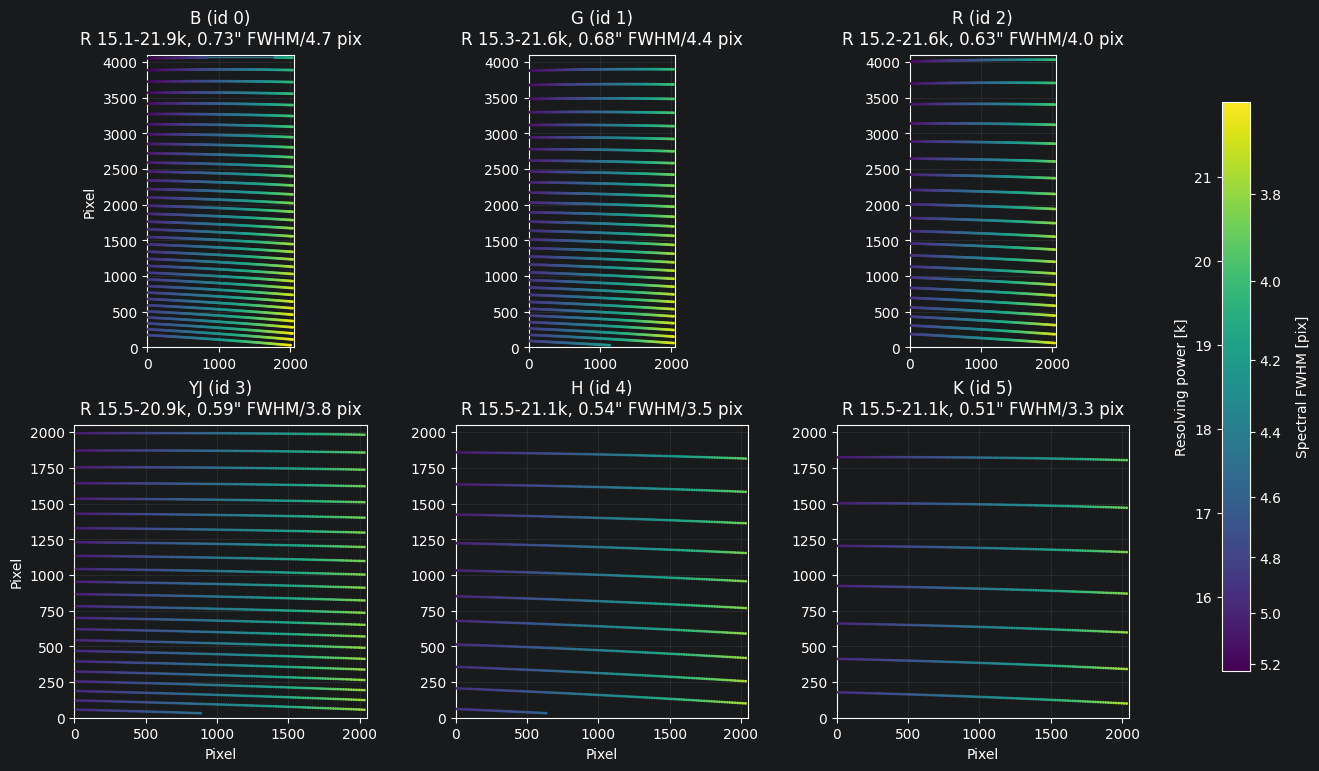

In [5]:
trace_resolution = trace_resolution_diagnostic_table(zs, samples_per_trace=128)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
display(trace_resolution_summary_display_table(trace_resolution_summary))

fig, axes = plot_trace_resolving_power_detector_maps(trace_resolution)
display(fig)
plt.close(fig)


## Model Inventory

This is the compact checklist of what is active in the simulator. A release validation notebook should make omissions as visible as included machinery. Total integrated scatter from bright sky lines is not yet a ScopeSim/IRDB effect; the relevant physics is shown later as a back-of-the-envelope scale and should become a follow-up ScopeSim effect.

In [6]:
inventory_rows = []
for effect in zs.optics_manager.all_effects:
    meta = getattr(effect, "meta", {}) or {}
    inventory_rows.append({
        "included": bool(getattr(effect, "include", True)),
        "effect": effect_name(effect),
        "class": effect.__class__.__name__,
        "selector": meta.get("selector_key", ""),
        "source file": meta.get("filename", ""),
    })
inventory = pd.DataFrame(inventory_rows)
display_frame(inventory[inventory["included"]])

known_omissions = pd.DataFrame([
    {"item": "Total integrated scatter (TIS)", "status": "not yet a ScopeSim effect", "consequence": "bright sky-line scatter/interline floor must be handled as a BoE note until implemented"},
    {"item": "Extracted-spectrum optimal aperture", "status": "not a detector readout product", "consequence": "readout/SNR images are per-pixel diagnostics, not a reduced spectrum"},
    {"item": "Science-specific observing sequence", "status": "user notebook layer", "consequence": "change DIT/NDIT/slit/source here before rerunning"},
])
display_frame(known_omissions)


included,effect,class,selector,source file
True,atmo_transmission,TERCurve,,TER_maunakea_tapas.dat
True,continuum_emission,SkyBackgroundTERCurve,,nan
True,airglow_and_interline_continuum,PalaceAirglowEmission,,nan
True,seeing_psf,AOEnhanceablePSF,,nan
True,adc_residuals,ADCShift,,adc_residuals.dat
True,telescope_reflection,SurfaceList,,LIST_keck_mirrors.dat
True,dichroic_tree,DichroicTree,,nan
True,slitwheel_selector,SelectorWheel,aperture_id,nan
True,channel_optics_selector,SelectorWheel,aperture_id,nan
True,trace_eff_analytical,EchelleSpectralEfficiency,,traces/echelle_trace_parameters.dat


item,status,consequence
Total integrated scatter (TIS),not yet a ScopeSim effect,bright sky-line scatter/interline floor must be handled as a BoE note until implemented
Extracted-spectrum optimal aperture,not a detector readout product,"readout/SNR images are per-pixel diagnostics, not a reduced spectrum"
Science-specific observing sequence,user notebook layer,change DIT/NDIT/slit/source here before rerunning


## Slit Loss, Seeing, AO Design Curves, And Atmospheric Dispersion

These plots are diagnostics for the optical geometry rather than extracted data products. The first plot uses color for seeing/AO, dash pattern for slit choice, opacity for airmass, and short tick marks on the line for ADC off. Line weight is reserved for the fully current observing combination. The slit legend uses `*` for the selected VIS slit and `^` for the selected NIR slit when a selected slit is one of the plotted extrema; when both arms use the same non-extremal selected slit, that shared style is labeled `Selected slit`. The second plot isolates PSF loss as a function of slit width. Legend labels pair VIS/NIR wavelengths by construction, for example `0.65" NS, 500/1250 nm`; if that pairing breaks, the plot should fail instead of silently changing meaning.


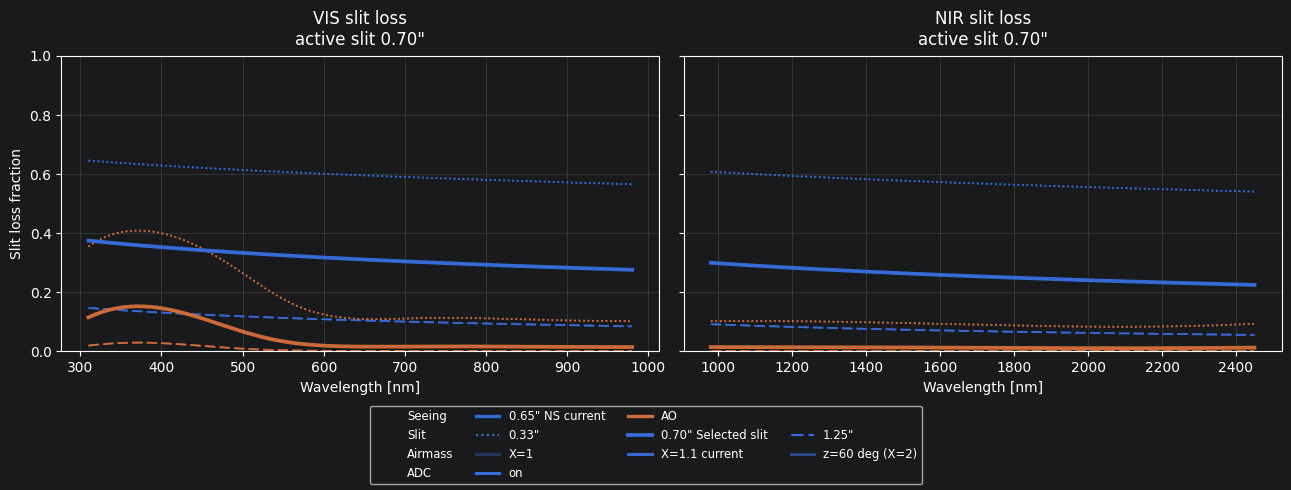

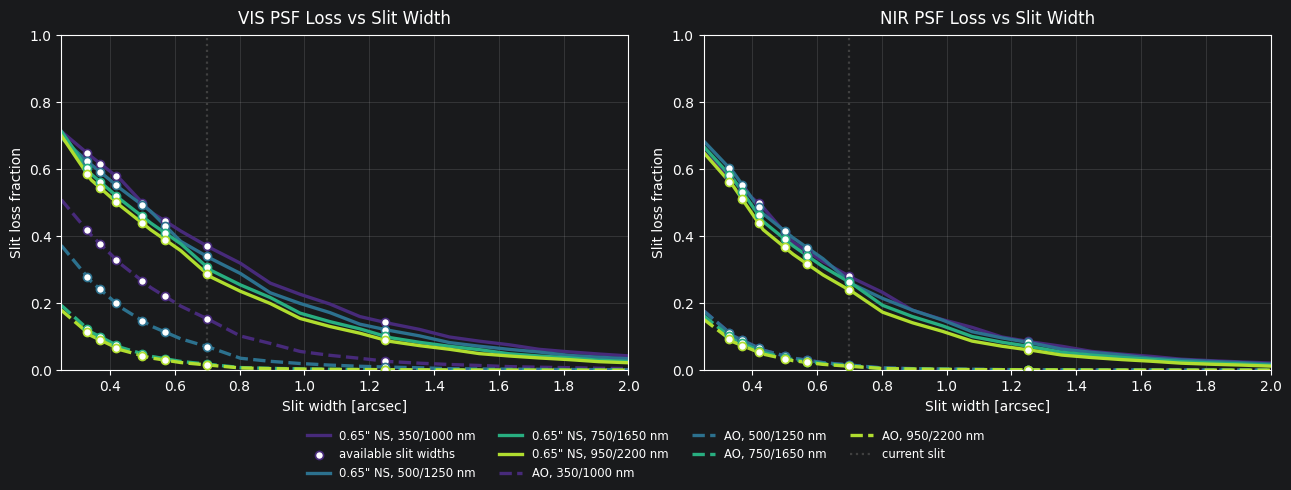

In [7]:
slit_loss_data = build_slit_loss_data(zs, n_wave=160, slit_length=10*u.arcsec, grid_step=0.04*u.arcsec)
fig, axes = plot_slit_loss_by_arm(slit_loss_data, show_airmass_states=True, show_adc_states=False)

slit_width_loss_data = build_slit_width_loss_data(zs, slit_length=10*u.arcsec, grid_step=0.04*u.arcsec)
fig, axes = plot_slit_width_loss(slit_width_loss_data)


In [8]:
slit_width_rows = []
for arm_name, arm in slit_width_loss_data["arms"].items():
    slit_widths = arm["slit_widths_arcsec"].to_value(u.arcsec)
    current_slit = arm["current_slit_width_arcsec"].to_value(u.arcsec)
    for curve in arm["curves"].values():
        slit_width_rows.append({
            "arm": arm_name,
            "PSF / ADC case": curve["psf_mode"],
            "wavelength [nm]": curve["wavelength_nm"],
            "active slit [arcsec]": current_slit,
            "transmission at active slit": np.interp(current_slit, slit_widths, curve["throughput"]),
            "loss at active slit": np.interp(current_slit, slit_widths, curve["loss"]),
        })
display_frame(
    slit_width_rows,
    formats={
        "wavelength [nm]": "{:.0f}",
        "active slit [arcsec]": "{:.2f}",
        "transmission at active slit": "{:.3f}",
        "loss at active slit": "{:.3f}",
    },
)

display_frame(slit_adc_psf_status_table(zs))


arm,PSF / ADC case,wavelength [nm],active slit [arcsec],transmission at active slit,loss at active slit
VIS,no_ao,350,0.70,0.630,0.370
VIS,no_ao,500,0.70,0.661,0.339
VIS,no_ao,750,0.70,0.692,0.308
VIS,no_ao,950,0.70,0.713,0.287
VIS,ao,350,0.70,0.847,0.153
VIS,ao,500,0.70,0.930,0.070
VIS,ao,750,0.70,0.982,0.018
VIS,ao,950,0.70,0.984,0.016
NIR,no_ao,1000,0.70,0.720,0.280
NIR,no_ao,1250,0.70,0.735,0.265


category,scope,name,class,setting,note
slit,"aperture_id 0, 1, 2, 3, 4, 5",slitwheel_selector,SlitWheel,current_slit=0.7,filename_format=slits/slit_{:.2f}_as.dat
adc optics,"aperture_id 0, 1, 2",channel_optics_selector,SurfaceList,"VIS_ADC_12, VIS_ADC_34",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
adc optics,"aperture_id 3, 4, 5",channel_optics_selector,SurfaceList,"NIR_ADC_1, NIR_ADC_2, NIR_ADC_3, NIR_ADC_4",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
atmospheric dispersion,global,adc_residuals,ADCShift,filename=adc_residuals.dat,
psf,global,seeing_psf,AOEnhanceablePSF,"filename=None, fwhm={'seeing': 0.65, 'seeing_unit': 'arcsec', 'pivot_wave': 500, 'pivot_wave_unit': 'nm'}, alpha=4.765",


## Throughput Components And Total

This figure has two jobs. The six small panels preserve the diagnostic decomposition: telescope/static optics, selected instrument optics, dichroics, disperser/order efficiencies, trace-position detector QE, and the resulting instrument/order curves. The all-channel panel underneath is the presentation summary: thin background curves show telescope, dichroic, optics, active slit transmission, and trace-QE median; dashed curves are `instrument` and solid curves are `total` after telescope and active slit transmission.


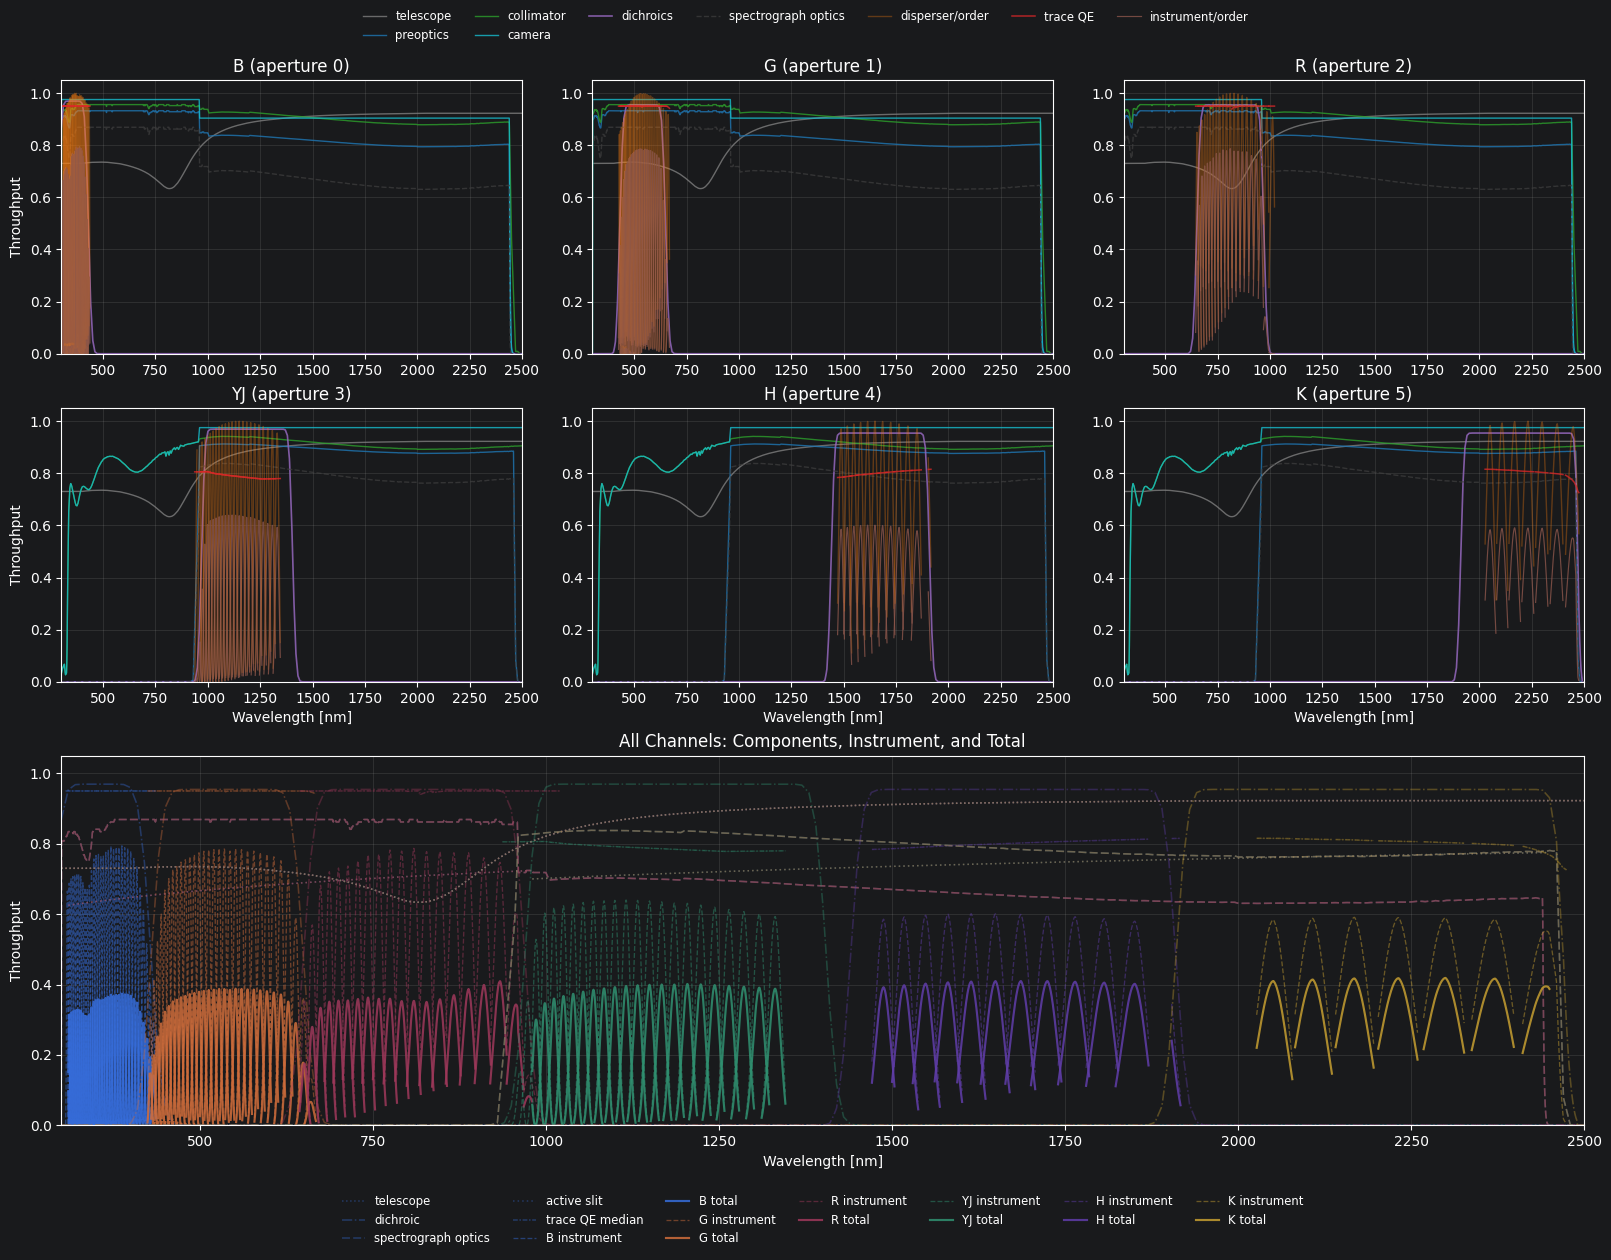

In [9]:
sim_wave_min_nm = u.Quantity(cmd_value("!SIM.spectral.wave_min"), u.um).to_value(u.nm)
sim_wave_max_nm = u.Quantity(cmd_value("!SIM.spectral.wave_max"), u.um).to_value(u.nm)
wave_nm = np.linspace(sim_wave_min_nm, sim_wave_max_nm, 5000) * u.nm
transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_transmission_sanity_data(transmission_data)
fig, axes = plot_transmission_sanity(transmission_data, slit_loss_data=slit_loss_data, summary_component_alpha=0.38, summary_component_linewidth=1.15)


In [10]:
def active_slit_transmission_for_channel(channel_label):
    arm_name = "VIS" if channel_label in ("B", "G", "R") else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(wave_values, arm["wave_nm"].to_value(u.nm), curve["throughput"], left=np.nan, right=np.nan)

throughput_rows = []
wave_values = transmission_data["wave_nm"].to_value(u.nm)
for aperture_id, channel in transmission_data["channels"].items():
    active_slit = active_slit_transmission_for_channel(channel["label"])
    order_peaks = []
    for trace_id, order in channel["orders"].items():
        total = np.asarray(order["total_with_telescope_no_slit"], dtype=float) * active_slit
        finite = np.isfinite(total)
        if not np.any(finite):
            continue
        peak_index = np.nanargmax(total)
        order_peaks.append((trace_id, wave_values[peak_index], total[peak_index]))
    best_trace, best_wave, best_throughput = max(order_peaks, key=lambda item: item[2])
    throughput_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "best_order": best_trace,
        "best_wave_nm": best_wave,
        "peak_instrument_throughput": np.nanmax([np.nanmax(order["instrument"]) for order in channel["orders"].values()]),
        "peak_total_throughput": best_throughput,
        "peak_pre_disperser_instrument": np.nanmax(channel["pre_disperser_instrument_total"]),
        "peak_telescope_throughput": np.nanmax(channel["telescope_throughput"]),
        "order_qe_method": "; ".join(channel["order_detector_qe_methods"]),
    })
throughput_summary = Table(rows=throughput_rows)
display_frame(
    throughput_summary,
    columns=["channel", "best_order", "best_wave_nm", "peak_instrument_throughput", "peak_total_throughput", "peak_pre_disperser_instrument", "peak_telescope_throughput", "order_qe_method"],
    rename={
        "best_order": "best order",
        "best_wave_nm": "best wave [nm]",
        "peak_instrument_throughput": "peak instrument",
        "peak_total_throughput": "peak total with telescope+slit",
        "peak_pre_disperser_instrument": "peak pre-disperser instrument",
        "peak_telescope_throughput": "peak telescope",
        "order_qe_method": "detector QE used by orders",
    },
    formats={
        "best wave [nm]": "{:.0f}",
        "peak instrument": "{:.3f}",
        "peak total with telescope+slit": "{:.3f}",
        "peak pre-disperser instrument": "{:.3f}",
        "peak telescope": "{:.3f}",
    },
)


channel,best order,best wave [nm],peak instrument,peak total with telescope+slit,peak pre-disperser instrument,peak telescope,detector QE used by orders
B,b_94,388,0.794,0.374,0.842,0.923,slit-center trace detector pixels
G,g_66,552,0.786,0.388,0.829,0.923,slit-center trace detector pixels
R,r_39,934,0.787,0.409,0.829,0.923,slit-center trace detector pixels
YJ,yj_63,1204,0.640,0.402,0.813,0.923,slit-center trace detector pixels
H,h_45,1686,0.601,0.410,0.769,0.923,slit-center trace detector pixels
K,k_33,2300,0.591,0.419,0.743,0.923,slit-center trace detector pixels


In [11]:
wave_q = transmission_data["wave_nm"].to(u.nm)
wave = wave_q.to_value(u.nm)

def _a(x):
    return np.asarray(getattr(x, "value", x), dtype=float)

def _mean(x, mask=None):
    x = _a(x)
    ok = np.isfinite(x) if mask is None else (mask & np.isfinite(x))
    return float(np.nanmean(x[ok])) if np.any(ok) else np.nan

def _cat(arrs):
    vals = [_a(a)[np.isfinite(_a(a))] for a in arrs]
    vals = [v for v in vals if v.size]
    return np.concatenate(vals) if vals else np.array([], dtype=float)

try:
    _, atmosphere = fetch_effect_spectrum_or_transmission(
        zs, "atmo_transmission", wave=wave_q
    )
    atmosphere = _a(atmosphere)
except Exception:
    atmosphere = np.full(wave.size, np.nan)

try:
    _trace_eff = get_effect(zs, "trace_eff_analytical")
except Exception:
    _trace_eff = None

def _slit_curve(channel_label):
    arm = slit_loss_data["arms"]["VIS" if channel_label in ("B", "G", "R") else "NIR"]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(
        wave, arm["wave_nm"].to_value(u.nm), curve["throughput"],
        left=np.nan, right=np.nan,
    )

def _xdisp(trace_id):
    try:
        spec = _trace_eff._spectrographs[str(trace_id).partition("_")[0]]
        return _a(spec.xdisp_efficiency(wave_q.to(u.um)))
    except Exception:
        return np.full(wave.size, np.nan)

rows = []
for aperture_id, ch in transmission_data["channels"].items():
    order_masks = [np.isfinite(_a(o["disperser"])) for o in ch["orders"].values()]
    band_mask = np.logical_or.reduce(order_masks) if order_masks else np.zeros(wave.size, bool)

    optics_terms = [
        _a(v) for k, v in ch["instrument_optics_groups"].items()
        if k != "ir_blocking_filter"
    ]
    optics = np.prod(optics_terms, axis=0) if optics_terms else np.ones(wave.size)

    trace_arrays = [_a(o["disperser"]) for o in ch["orders"].values()]
    qe_arrays = [_a(o["detector_qe"]) for o in ch["orders"].values()]
    xdisp_arrays = []
    for trace_id, order in ch["orders"].items():
        xdisp = _a(order["xdisperser"]) if "xdisperser" in order else _xdisp(trace_id)
        xdisp_arrays.append(np.where(np.isfinite(_a(order["disperser"])), xdisp, np.nan))

    trace_vals = _cat(trace_arrays)
    qe_vals = _cat(qe_arrays)
    xdisp_vals = _cat(xdisp_arrays)
    trace_peaks = [np.nanmax(a) for a in trace_arrays if np.isfinite(a).any()]

    rows.append({
        "band": ch["label"],
        "telescope": _mean(ch["telescope_throughput"], band_mask),
        "atmosphere": _mean(atmosphere, band_mask),
        "slit": _mean(_slit_curve(ch["label"]), band_mask),
        "dichroic": _mean(ch["dichroic_total"], band_mask),
        "optics": _mean(optics, band_mask),
        "trace peak efficiency": float(np.nanmean(trace_peaks)) if trace_peaks else np.nan,
        "mean trace efficiency FSR": float(np.nanmean(trace_vals)) if trace_vals.size else np.nan,
        "mean xdisperser efficiency": float(np.nanmean(xdisp_vals)) if xdisp_vals.size else np.nan,
        "mean QE": float(np.nanmean(qe_vals)) if qe_vals.size else np.nan,
    })
    rows[-1]['total excl atm.']=np.prod([rows[-1][k] for k in ('telescope','slit','dichroic','optics','trace peak efficiency','mean xdisperser efficiency','mean QE')])

throughput_component_means = pd.DataFrame(rows).set_index("band")
display(throughput_component_means.style.format("{:.3f}", na_rep="--"))

,telescope,atmosphere,slit,dichroic,optics,trace peak efficiency,mean trace efficiency FSR,mean xdisperser efficiency,mean QE,total excl atm.
band,,,,,,,,,,
B,0.731,0.693,0.641,0.894,0.844,0.968,0.347,0.975,0.950,0.317
G,0.729,0.911,0.674,0.847,0.869,0.953,0.482,0.959,0.950,0.313
R,0.709,0.962,0.708,0.803,0.839,0.954,0.663,0.957,0.950,0.293
YJ,0.864,0.962,0.714,0.892,0.811,0.969,0.499,0.973,0.791,0.333
H,0.917,0.876,0.745,0.939,0.786,0.978,0.686,0.988,0.800,0.389
K,0.923,0.945,0.768,0.937,0.752,0.991,0.790,0.992,0.802,0.393


## Source Construction And Slit Coordinates

Use the slit-frame convention consistently: `x` is along the slit length and `y` is across the slit width. There are two source-construction paths here, and they are not interchangeable. `scopesim_templates.star` should receive scalar coordinates, for example `x=0`, `y=0`; one-element lists create `(1, 1)` table columns in this environment and can break ScopeSim FOV extraction. Low-level table-backed sources should use one-dimensional arrays, as `field_angle_demo_sources` does internally. The cells below keep those conventions visible next to the source calls.

In [12]:
source_brightness_m_am = 20

source_angle_on_slit = angle_from_cmds(cmd, "!OBS.pupil_angle")
slit_demo_sources = field_angle_demo_sources(along_separation=5.0*u.arcsec, across_separation=0.9*u.arcsec, angle_on_slit=source_angle_on_slit, along_mag=source_brightness_m_am, across_mag=source_brightness_m_am)
star_on_slit_center = sim_tp.star('V',source_brightness_m_am*u.ABmag, spec_type="A0V", x=0, y=0, library="pyckles")
star_on_slit_plus2 = sim_tp.star('V',source_brightness_m_am*u.ABmag, spec_type="A0V", x=2, y=0, library="pyckles")
constant_photon_flat = constant_photon_flux_flat(amplitude=0.001, extent=60)
calibration_lamp = lamp_flat(zshooter_dir=zshooter_dir, resolving_power=80000, wave_step=0.05*u.AA, extent=60)

from scopesim.source.source import Source
from scopesim.source.source_templates import ab_spectrum
flat_ab_point_table = Table(
    data=[
        [0.0],                       # x: along slit
        [0.0],                       # y: across slit
        [1.0],                       # weight
        [0],                         # ref -> spectra[0]
        ["flat_ab_point_center"],
    ],
    names=["x", "y", "weight", "ref", "label"],
    units=[u.arcsec, u.arcsec, None, None, None],
)

flat_ab_point_center = Source(
    table=flat_ab_point_table,
    spectra=[ab_spectrum(mag=source_brightness_m_am)],
)


slit_validation_sources = OrderedDict()
slit_validation_sources["star_center"] = star_on_slit_center
slit_validation_sources["star_plus2_along_slit"] = star_on_slit_plus2
slit_validation_sources["flat_ab_point_center"] = flat_ab_point_center
slit_validation_sources.update(slit_demo_sources)

source_to_observe = slit_validation_sources["flat_ab_point_center"]
for name, source in slit_validation_sources.items():
    print(name)
    display_frame(source_position_table(source))

star_center


x,y,ref,weight,spec_types
0.000000,0.000000,0,0.000000,A0V


star_plus2_along_slit


x,y,ref,weight,spec_types
2.000000,0.000000,0,0.000000,A0V


flat_ab_point_center


x,y,weight,ref,label
0.000000,0.000000,1.000000,0,flat_ab_point_center


along_slit_centered


x,y,weight,ref,label
-2.500000,0.000000,1.000000,0,source_0
2.500000,0.000000,1.000000,0,source_1


across_slit_one_off


x,y,weight,ref,label
0.000000,0.000000,1.000000,0,source_0
0.000000,0.900000,1.000000,0,source_1


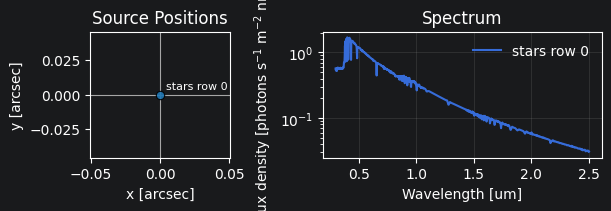

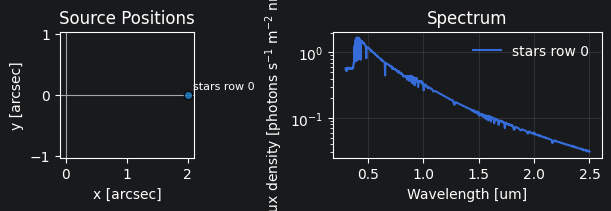

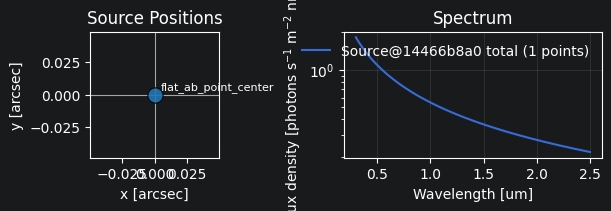

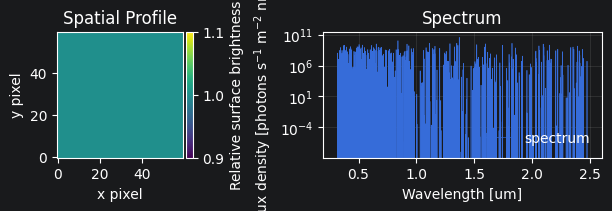

In [13]:
fig, axes = plot_source(star_on_slit_center, individual=True, spectrum_yscale="log")
fig, axes = plot_source(star_on_slit_plus2, individual=True, spectrum_yscale="log")
fig, axes = plot_source(flat_ab_point_center, spectrum_yscale="log")
lamp_plot_wave = np.linspace(0.3, 2.5, 12000) * u.um
fig, axes = plot_source(calibration_lamp, wave=lamp_plot_wave, spectrum_yscale="log", spectrum_linewidth=0.45)

## Multi-Star Slit/ADC/PSF Scene

This is the visual geometry check: it shows where table-backed sources land in the slit frame, then convolves the positions with the configured PSF and atmospheric-dispersion/ADC residual model. It is not a detector readout and should not be interpreted as extracted flux.

along_slit_centered


source_index,label,x_arcsec,y_arcsec,in_slit
0,source_0,-2.500000,0.000000,True
1,source_1,2.500000,0.000000,True


across_slit_one_off


source_index,label,x_arcsec,y_arcsec,in_slit
0,source_0,0.000000,0.000000,True
1,source_1,0.000000,0.900000,False


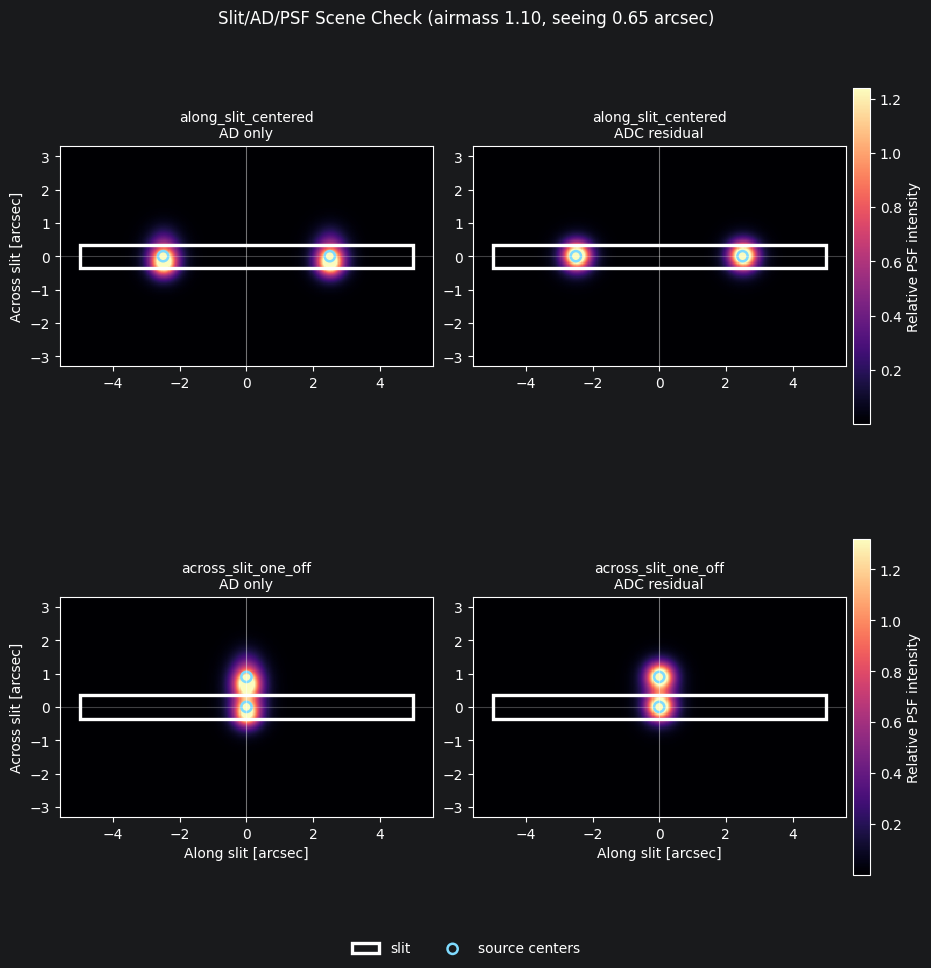

In [14]:
slit_scene_data = build_slit_adc_psf_scene_data(zs, slit_demo_sources, slit_width=cmd_value("!INST.vis_curr_slit")*u.arcsec, slit_length=10*u.arcsec, grid_step=0.035*u.arcsec)
fig, axes = plot_slit_adc_psf_scenes(slit_scene_data)
for name, scenario in slit_scene_data["scenarios"].items():
    print(name)
    display_frame(scenario["status"])

## Background Budget: Sky, Telescope, Instrument, Detector

The goal here is not just to list components but to make them comparable. The emissivity and post-disperser diffuse tables report photon/electron rates in detector-relevant units, while the detailed surface rows remain available for debugging. Telescope mirror emission must appear as a pre-disperser term; if it disappears, the optical accounting is incomplete.

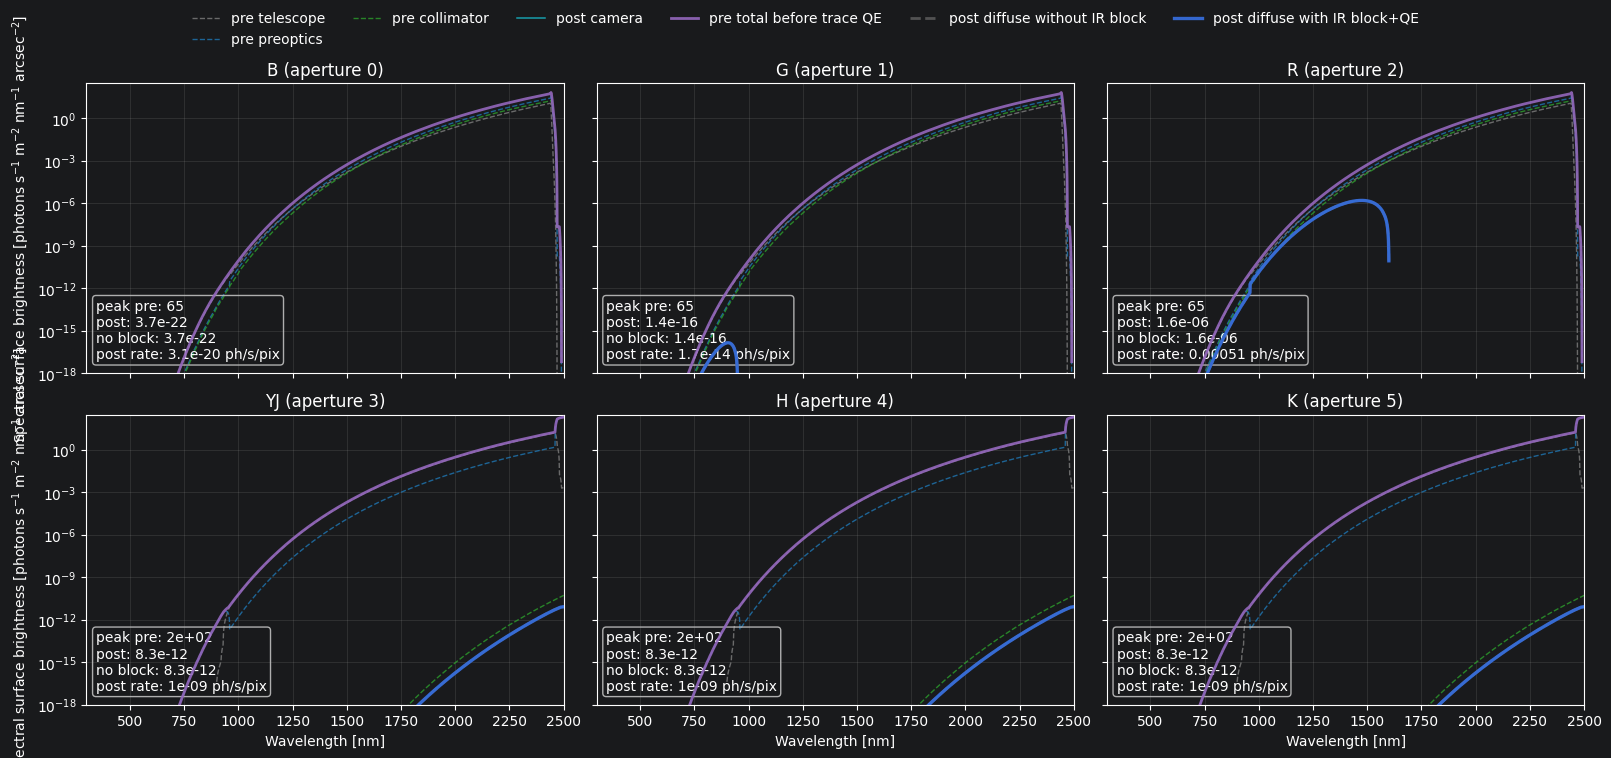

In [15]:
emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)

In [16]:
emissivity_rows = []
for aperture_id, channel in emissivity_data["channels"].items():
    telescope = channel["pre_disperser_terms"].get("telescope", np.zeros_like(channel["pre_disperser_output_equiv"]))
    pre_no_telescope = channel["pre_disperser_output_equiv"] - telescope
    emissivity_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "peak_telescope_thermal_photlam_equiv": np.nanmax(telescope),
        "peak_other_pre_disperser_photlam_equiv": np.nanmax(pre_no_telescope),
        "peak_post_after_qe_photlam_equiv": np.nanmax(channel["post_disperser_after_qe"]),
        "post_diffuse_ph_s_pix": channel["post_disperser_rate_ph_s_pix"],
        "post_diffuse_without_ir_block_ph_s_pix": channel["post_disperser_without_blocking_rate_ph_s_pix"],
        "removed_by_ir_block_ph_s_pix": channel["post_disperser_without_blocking_rate_ph_s_pix"] - channel["post_disperser_rate_ph_s_pix"],
    })
emissivity_summary = Table(rows=emissivity_rows)
display_frame(
    emissivity_summary,
    columns=["channel", "peak_telescope_thermal_photlam_equiv", "peak_other_pre_disperser_photlam_equiv", "peak_post_after_qe_photlam_equiv", "post_diffuse_ph_s_pix", "post_diffuse_without_ir_block_ph_s_pix", "removed_by_ir_block_ph_s_pix"],
    rename={
        "peak_telescope_thermal_photlam_equiv": "peak telescope thermal [ph/s/cm2/A equiv]",
        "peak_other_pre_disperser_photlam_equiv": "peak other pre-disperser [ph/s/cm2/A equiv]",
        "peak_post_after_qe_photlam_equiv": "peak post-disperser after QE [ph/s/cm2/A equiv]",
        "post_diffuse_ph_s_pix": "post diffuse [ph/s/pix]",
        "post_diffuse_without_ir_block_ph_s_pix": "post diffuse no IR block [ph/s/pix]",
        "removed_by_ir_block_ph_s_pix": "removed by IR block [ph/s/pix]",
    },
    formats={
        "peak telescope thermal [ph/s/cm2/A equiv]": "{:.3e}",
        "peak other pre-disperser [ph/s/cm2/A equiv]": "{:.3e}",
        "peak post-disperser after QE [ph/s/cm2/A equiv]": "{:.3e}",
        "post diffuse [ph/s/pix]": "{:.3e}",
        "post diffuse no IR block [ph/s/pix]": "{:.3e}",
        "removed by IR block [ph/s/pix]": "{:.3e}",
    },
)

surface_debug_columns = ["channel", "component", "surface", "group", "emission_phase", "action", "temperature", "emissivity_source", "transmission_source", "peak_after_qe"]
display_frame(
    emissivity_data["details"],
    columns=surface_debug_columns,
    rename={
        "emission_phase": "emission phase",
        "temperature": "temperature [K]",
        "emissivity_source": "emissivity source",
        "transmission_source": "transmission source",
        "peak_after_qe": "peak after QE [ph/s/cm2/A equiv]",
    },
    formats={"temperature [K]": "{:.0f}", "peak after QE [ph/s/cm2/A equiv]": "{:.3e}"},
)


channel,peak telescope thermal [ph/s/cm2/A equiv],peak other pre-disperser [ph/s/cm2/A equiv],peak post-disperser after QE [ph/s/cm2/A equiv],post diffuse [ph/s/pix],post diffuse no IR block [ph/s/pix],removed by IR block [ph/s/pix]
B,1.143e-04,6.069e-04,3.689e-27,3.100e-20,3.100e-20,0.000e+00
G,1.143e-04,6.069e-04,1.403e-21,1.746e-14,1.746e-14,0.000e+00
R,1.143e-04,6.069e-04,1.570e-11,5.067e-04,5.067e-04,0.000e+00
YJ,1.590e-04,2.017e-03,8.311e-17,1.043e-09,1.043e-09,0.000e+00
H,1.590e-04,2.017e-03,8.311e-17,1.043e-09,1.043e-09,0.000e+00
K,1.590e-04,2.017e-03,8.311e-17,1.043e-09,1.043e-09,0.000e+00


channel,component,surface,group,emission phase,action,temperature [K],emissivity source,transmission source,peak after QE [ph/s/cm2/A equiv]
B,telescope_reflection,M1,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.708e-05
B,telescope_reflection,M2,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.809e-05
B,telescope_reflection,M3,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.912e-05
B,channel_optics_selector,VIS_Fold,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,2.651e-05
B,channel_optics_selector,VIS_PreOptFirst,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,4.555e-05
B,channel_optics_selector,VIS_ADC_12,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,5.008e-05
B,channel_optics_selector,VIS_ADC_34,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,5.515e-05
B,channel_optics_selector,VIS_Derotator_AR_1,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,6.207e-05
B,channel_optics_selector,VIS_Derotator_AR_2,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,7.043e-05
B,channel_optics_selector,VIS_Derotator_Refl_1,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.005e-05


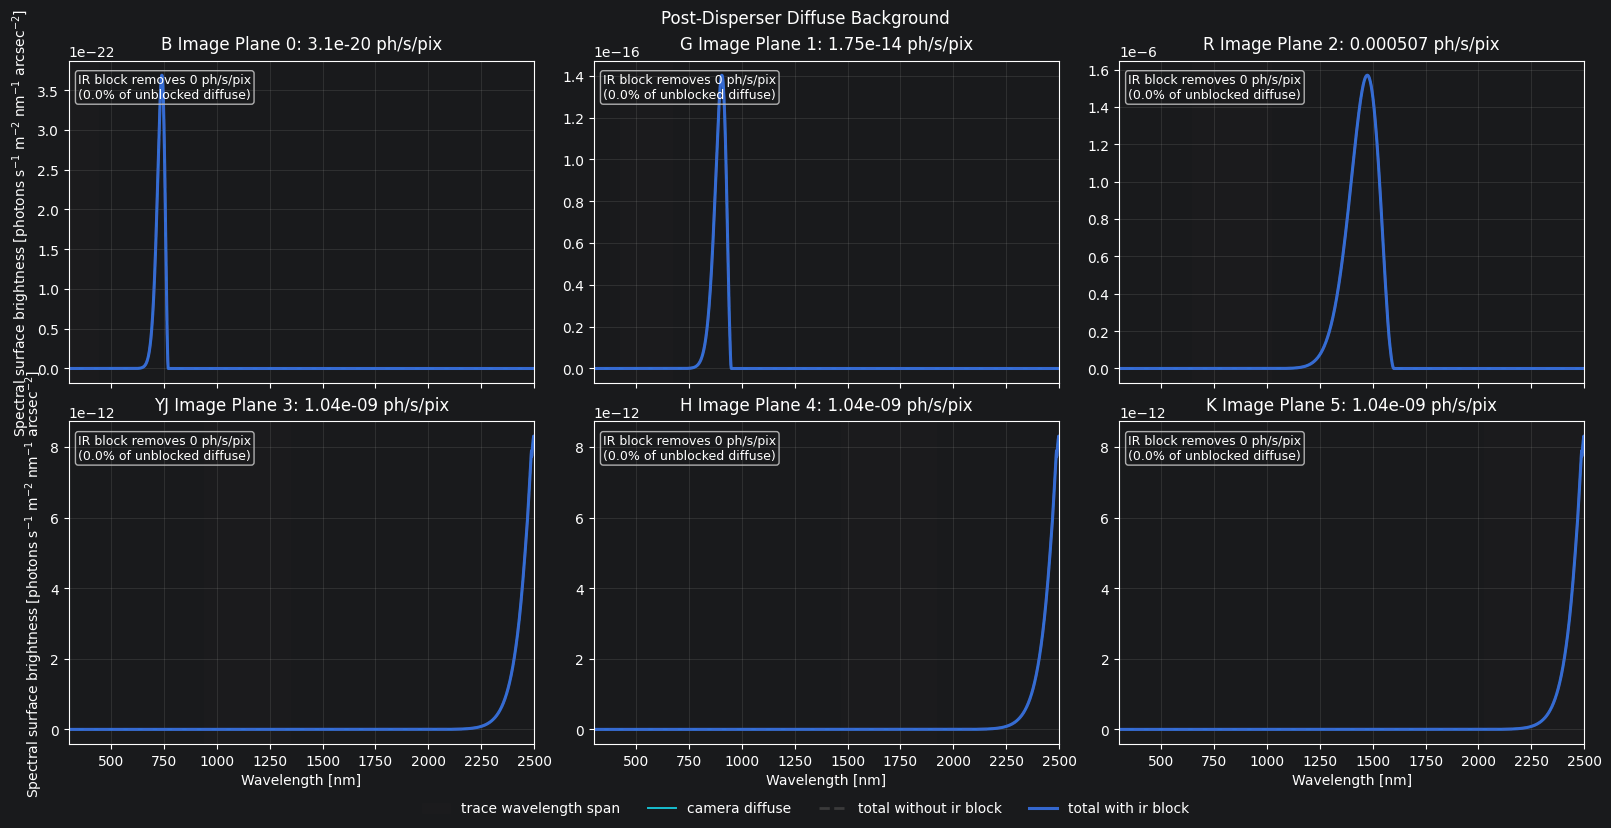

In [17]:
post_diffuse_data = build_post_disperser_diffuse_background_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_post_disperser_diffuse_background_data(post_diffuse_data)
fig, axes = plot_post_disperser_diffuse_background(post_diffuse_data)

if cmd["!INST.include_diffuse_emmisivity"]:
    post_diffuse_consistency = post_disperser_diffuse_effect_consistency_table(zs, post_diffuse_data, qe_selector_name=None, component_metadata=component_metadata)
    validate_post_disperser_diffuse_effect_consistency(post_diffuse_consistency)
    display_frame(post_diffuse_consistency)

In [18]:
qe_accounting = detector_qe_accounting_table(transmission_data, emissivity_data, post_diffuse_data)
display_frame(qe_accounting)

detector_geometry = detector_geometry_table(zs)
display_frame(detector_geometry)
display_frame(detector_selector_matrix(zs))


path,aperture_id,channel,qe_model,trace_mapped_qe,transmission_plot_qe,diffuse_qe,diffuse_position_samples,order_qe_methods,position_axis,position_min,position_max
transmission_trace_mapped,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,4,H,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,5,K,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
emissivity_sanity,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,,nan,None,None


detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
0,0,B,CCD_B,2048,4096,0.015000,1.000000
1,1,G,CCD_G,2048,4096,0.015000,1.000000
2,2,R,CCD_R,2048,4096,0.015000,1.000000
3,3,YJ,APD_YJ,2048,2048,0.015000,1.000000
4,4,H,APD_H,2048,2048,0.015000,1.000000
5,5,K,APD_K,2048,2048,0.015000,1.000000


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,"filename=None, current_slit=0.7"
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,TaperedQuantumEfficiency,filename=None
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=1800, ndit=2"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=1800, ndit=2, value=1e-05"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=2, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,"filename=None, current_slit=0.7"
1,G,CCD_G,channel_optics_selector,aperture_id,1,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat


detector_id,image_plane_id,channel,detector,dit_s,ndit,exposure_time_s,post_diffuse_rate_ph_s_pix,post_diffuse_e_pix,dark_current_e_s_pix,dark_current_e_pix,additive_signal_e_pix,bias_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,read_noise_e_rms,diffuse_shot_noise_e_rms,dark_shot_noise_e_rms,total_noise_e_rms
0,0,B,CCD_B,1800.000000,2.000000,3600.000000,0.000000,0.000000,0.000010,0.036000,0.036000,1040.000000,64000.000000,0.000001,ok,0.141421,0.000000,0.189737,0.236643
1,1,G,CCD_G,1800.000000,2.000000,3600.000000,0.000000,0.000000,0.000010,0.036000,0.036000,1040.000000,64000.000000,0.000001,ok,0.141421,0.000008,0.189737,0.236643
2,2,R,CCD_R,1800.000000,2.000000,3600.000000,0.000507,1.823953,0.000010,0.036000,1.859953,1040.000000,64000.000000,0.000029,ok,0.141421,1.350538,0.189737,1.371114
3,3,YJ,APD_YJ,1800.000000,2.000000,3600.000000,0.000000,0.000004,0.000010,0.036000,0.036004,1040.000000,64000.000000,0.000001,ok,0.707107,0.001938,0.189737,0.732123
4,4,H,APD_H,1800.000000,2.000000,3600.000000,0.000000,0.000004,0.000010,0.036000,0.036004,1040.000000,64000.000000,0.000001,ok,0.707107,0.001938,0.189737,0.732123
5,5,K,APD_K,1800.000000,2.000000,3600.000000,0.000000,0.000004,0.000010,0.036000,0.036004,1040.000000,64000.000000,0.000001,ok,0.707107,0.001938,0.189737,0.732123


detector_id,image_plane_id,channel,detector,current_slit_arcsec,wavelength_mid_nm,spectral_resolution_R,resolution_element_nm,pixel_area_arcsec2,post_diffuse_ph_s_pix,post_diffuse_ph_s_arcsec2,extraction_pixels,post_diffuse_ph_s_extraction,post_diffuse_e_extraction,additive_signal_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,note
0,0,B,CCD_B,0.700000,371.580034,40000.000000,0.009290,0.024199,0.000000,0.000000,4.000000,0.000000,0.000000,0.036000,64000.000000,0.000001,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
1,1,G,CCD_G,0.700000,546.289303,40000.000000,0.013657,0.024199,0.000000,0.000000,4.000000,0.000000,0.000000,0.036000,64000.000000,0.000001,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
2,2,R,CCD_R,0.700000,832.536444,40000.000000,0.020813,0.024199,0.000507,0.020937,4.000000,0.002027,7.295813,1.859953,64000.000000,0.000029,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
3,3,YJ,APD_YJ,0.700000,1141.588625,40000.000000,0.028540,0.024199,0.000000,0.000000,4.000000,0.000000,0.000015,0.036004,64000.000000,0.000001,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
4,4,H,APD_H,0.700000,1693.905760,40000.000000,0.042348,0.024199,0.000000,0.000000,4.000000,0.000000,0.000015,0.036004,64000.000000,0.000001,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
5,5,K,APD_K,0.700000,2250.713059,40000.000000,0.056268,0.024199,0.000000,0.000000,4.000000,0.000000,0.000015,0.036004,64000.000000,0.000001,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."


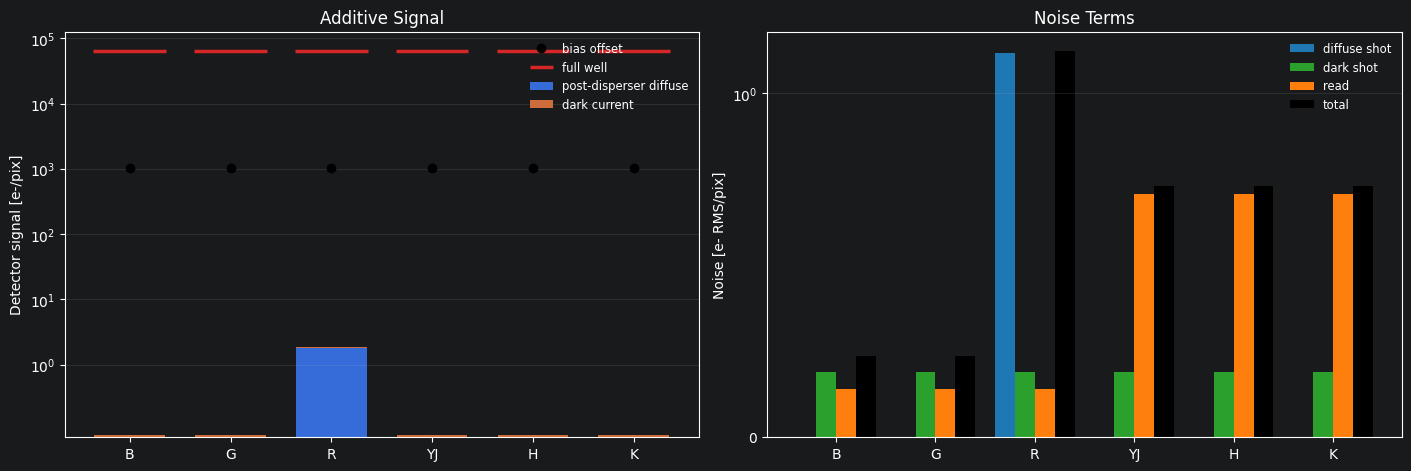

In [19]:
detector_budget = detector_background_budget_table(zs, post_diffuse_data=post_diffuse_data, post_diffuse_consistency=post_diffuse_consistency if  cmd["!INST.include_diffuse_emmisivity"] else None)
fig, axes = plot_detector_background_budget(detector_budget)
display_frame(detector_budget)

science_truth_checks = science_truth_crosscheck_table(zs, post_diffuse_data=post_diffuse_data, detector_budget=detector_budget, extraction_pixels=4.0)
display_frame(science_truth_checks)


## Sky Spectrum Components

This plots the active sky/background spectra in the same run configuration. `atmo_transmission` is multiplicative; with no source and sky emission disabled, it multiplies zero and has no impact on an empty-scene readout. Its thermal `emission` term is still an additive sky-background component. ScopeSim/Synphot emission spectra are PHOTLAM-like and are treated by ScopeSim's diffuse-background integrator as per square arcsecond, so this section converts them to photons s^-1 m^-2 nm^-1 arcsec^-2. The second plot shows the cumulative additive sky floor; airglow-line peak density is shown on the model evaluation grid, so detector-rate comparisons should integrate or rebin to the relevant trace/slit resolving power.

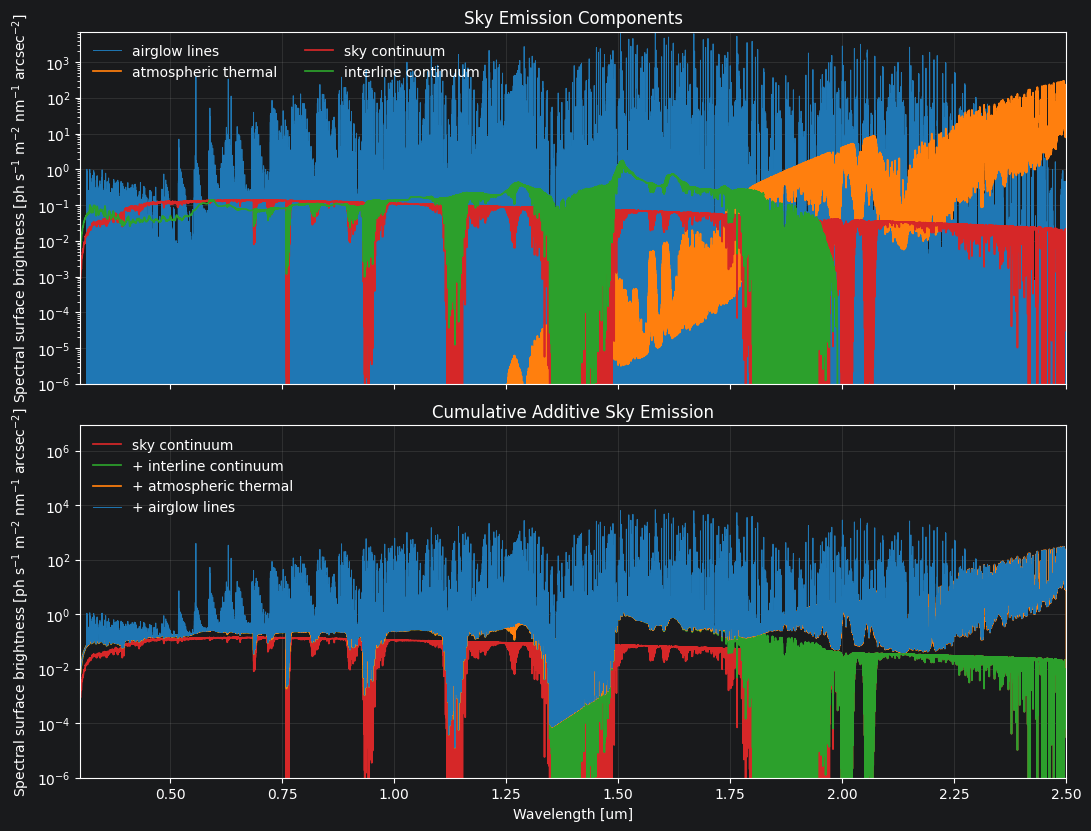

In [46]:
from synphot.units import PHOTLAM

PHOTLAM_TO_PH_S_M2_NM_ARCSEC2 = 1e5
SKY_WAVE_MIN_UM = 0.3
SKY_WAVE_MAX_UM = 2.5
SKY_SURFACE_BRIGHTNESS_LABEL = (
    r"Spectral surface brightness "
    r"[ph s$^{-1}$ m$^{-2}$ nm$^{-1}$ arcsec$^{-2}$]"
)

sky_effects = OrderedDict([
    ("airglow lines", ("airglow_and_interline_continuum", "line_TER.emission")),
    ("atmospheric thermal", ("atmo_transmission", "emission")),
    ("sky continuum", ("continuum_emission", "emission")),
    ("interline continuum", ("airglow_and_interline_continuum", "continuum_TER.emission")),

])
sky_colors = OrderedDict([
    ("sky continuum", "tab:red"),
    ("interline continuum", "tab:green"),
    ("atmospheric thermal", "tab:orange"),
    ("airglow lines", "tab:blue"),
])

def _sky_surface_brightness(values):
    return (
        u.Quantity(values).to_value(PHOTLAM)
        * PHOTLAM_TO_PH_S_M2_NM_ARCSEC2
    )

def _positive_for_log(values):
    values = np.asarray(values, dtype=float)
    return np.where(values > 0, values, np.nan)

sky_components = OrderedDict()
for label, (effect_name_text, attribute) in sky_effects.items():
    wave_um, values = fetch_effect_spectrum_or_transmission(
        zs, effect_name_text, attribute,
    )
    mask = (wave_um >= SKY_WAVE_MIN_UM * u.um) & (wave_um <= SKY_WAVE_MAX_UM * u.um)
    sky_components[label] = {
        "wave_um": wave_um[mask].to_value(u.um),
        "surface_brightness": _sky_surface_brightness(u.Quantity(values)[mask]),
    }

fig, axes = plt.subplots(2, 1, figsize=(10.8, 8.2), sharex=True, constrained_layout=True)

ax = axes[0]
for label, component in sky_components.items():
    ax.plot(
        component["wave_um"],
        _positive_for_log(component["surface_brightness"]),
        lw=0.7 if label == "airglow lines" else 1.25,
        color=sky_colors[label],
        label=label,
    )
ax.set_ylim(10**-6, None)
ax.set_title("Sky Emission Components")
ax.set_ylabel(SKY_SURFACE_BRIGHTNESS_LABEL)
ax.set_yscale("log")
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)

cumulative_wave_um = sky_components["airglow lines"]["wave_um"]
running = np.zeros_like(cumulative_wave_um, dtype=float)

ax = axes[1]
for label in ("sky continuum", "interline continuum", "atmospheric thermal", "airglow lines"):
    component = sky_components[label]
    values = np.nan_to_num(component["surface_brightness"], nan=0.0, posinf=0.0, neginf=0.0)
    running += np.interp(
        cumulative_wave_um,
        component["wave_um"],
        values,
        left=0.0,
        right=0.0,
    )
    ax.plot(
        cumulative_wave_um,
        _positive_for_log(running),
        lw=0.7 if label == "airglow lines" else 1.25,
        color=sky_colors[label],
        label=(
            "sky continuum"
            if label == "sky continuum"
            else f"+ {label}"
        ),
    )

ax.set_title("Cumulative Additive Sky Emission")
ax.set_xlabel("Wavelength [um]")
ax.set_ylabel(SKY_SURFACE_BRIGHTNESS_LABEL)
ax.set_yscale("log")
ax.set_ylim(10**-6, None)
ax.set_xlim(SKY_WAVE_MIN_UM, SKY_WAVE_MAX_UM)
ax.grid(alpha=0.2)
ax.legend(frameon=False)


## TIS Back-Of-The-Envelope Anchor

Total integrated scatter from bright sky lines is still a follow-up ScopeSim/IRDB effect. The CDR notebook uses the same physical shape shown here: `TIS = (4 pi sigma / lambda)^2`, then the camera accepts roughly `TIS * Omega_camera / (2 pi)` for a reflective grating scatter hemisphere. This is not added to the readout below; it is the scale that should be promoted into an instrument effect in a separate atomic ScopeSim/IRDB change.

term,expression,status
TIS,(4*pi*sigma/lambda)^2,BoE only here
camera acceptance,TIS * Omega_camera / (2*pi),needs ScopeSim effect
detector distribution,"requires line source, scatter kernel, and detector geometry",follow-up atomic ScopeSim/IRDB change


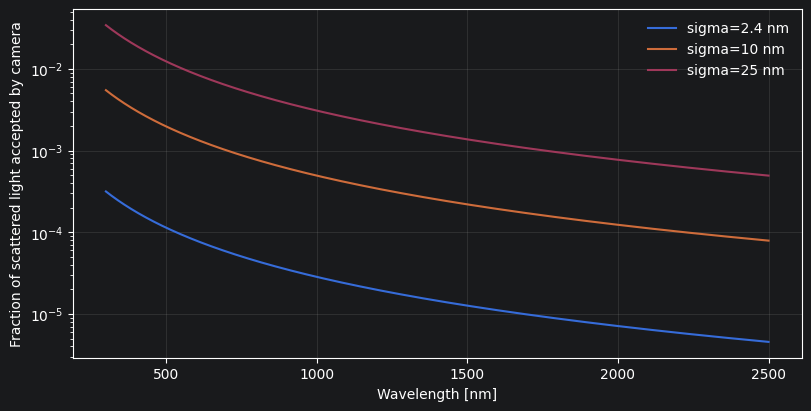

In [21]:
def tis_fraction_into_camera(wave_nm, surface_roughness_rms_nm=2.4, camera_fnum=2.0):
    wave_nm = np.asarray(wave_nm, dtype=float)
    tis = (4*np.pi*surface_roughness_rms_nm/wave_nm)**2
    camera_solid_angle = np.pi/(4*camera_fnum**2)
    return tis * camera_solid_angle/(2*np.pi)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for sigma_nm in (2.4, 10.0, 25.0):
    ax.plot(wave_nm.to_value(u.nm), tis_fraction_into_camera(wave_nm.to_value(u.nm), sigma_nm), label=f"sigma={sigma_nm:g} nm")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Fraction of scattered light accepted by camera")
ax.set_yscale("log")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

tis_notes = Table(rows=[
    {"term": "TIS", "expression": "(4*pi*sigma/lambda)^2", "status": "BoE only here"},
    {"term": "camera acceptance", "expression": "TIS * Omega_camera / (2*pi)", "status": "needs ScopeSim effect"},
    {"term": "detector distribution", "expression": "requires line source, scatter kernel, and detector geometry", "status": "follow-up atomic ScopeSim/IRDB change"},
])
display_frame(tis_notes)

## Source Photon Scale

This is explicit back-of-the-envelope math in the notebook. It does not call ScopeSim source internals. The source term uses the AB definition over one `lambda/R` element, telescope collecting area, representative order throughput, and the active point-source slit throughput. The sky term is a continuum sanity scale per arcsec2 and uses an explicit extraction solid angle; sky lines and diffuse backgrounds are checked by the readout scenarios below.


In [22]:
BOE_H_J_S = 6.62607015e-34
BOE_AB_ZERO_W_M2_HZ = 3631e-26
boe_source_abmag = source_brightness_m_am
boe_resolution = 18000.0
boe_telescope_diameter_m = 10.0
boe_geometric_10m_area_m2 = np.pi * (0.5 * boe_telescope_diameter_m)**2
boe_slit_curve_name = "no_ao_current_adc_residual"
boe_sky_ab_arcsec2 = OrderedDict([
    ("B", 21.18),
    ("G", 20.75),
    ("R", 20.40),
    ("YJ", 20.10),
    ("H", 20.10),
    ("K", 20.10),
])

def boe_ph_s_resel_at_telescope(abmag, resolving_power, area_m2, solid_angle_arcsec2=1.0):
    fnu = BOE_AB_ZERO_W_M2_HZ * 10**(-0.4 * float(abmag))
    return fnu / (BOE_H_J_S * float(resolving_power)) * float(area_m2) * float(solid_angle_arcsec2)

def boe_collecting_area_from_train(train):
    area = u.Quantity(from_currsys("!TEL.area", train.cmds))
    if area.unit == u.dimensionless_unscaled:
        area = area.value * u.m**2
    area_m2 = area.to_value(u.m**2)
    if not np.isfinite(area_m2) or area_m2 <= 0:
        raise ValueError("Built optical train has no positive !TEL.area; check the telescope SurfaceList / mirror list.")
    return float(area_m2)

boe_collecting_area_m2 = boe_collecting_area_from_train(zs)

def boe_channel_midpoint_and_throughput(channel, wave_grid_nm):
    finite_ranges = []
    throughput_values = []
    for order in channel["orders"].values():
        key = "total_with_telescope_no_slit" if "total_with_telescope_no_slit" in order else "total"
        total = np.asarray(order[key], dtype=float)
        finite = np.isfinite(total)
        if np.any(finite):
            finite_ranges.append((np.nanmin(wave_grid_nm[finite]), np.nanmax(wave_grid_nm[finite])))
    wave_mid_nm = 0.5 * (min(lo for lo, _hi in finite_ranges) + max(hi for _lo, hi in finite_ranges))
    for order in channel["orders"].values():
        key = "total_with_telescope_no_slit" if "total_with_telescope_no_slit" in order else "total"
        total = np.asarray(order[key], dtype=float)
        finite = np.isfinite(total)
        if np.any(finite) and np.nanmin(wave_grid_nm[finite]) <= wave_mid_nm <= np.nanmax(wave_grid_nm[finite]):
            throughput_values.append(float(np.interp(wave_mid_nm, wave_grid_nm[finite], total[finite])))
    return wave_mid_nm, float(np.nanmax(throughput_values))

def boe_slit_transmission(channel_label, wave_mid_nm, curve_name=boe_slit_curve_name):
    arm_name = "VIS" if channel_label in {"B", "G", "R"} else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"][curve_name]
    arm_wave_nm = u.Quantity(arm["wave_nm"]).to_value(u.nm)
    return float(np.interp(wave_mid_nm, arm_wave_nm, np.asarray(curve["throughput"], dtype=float)))

def boe_row_for_channel(aperture_id, channel, trace_summary_by_channel, budget_by_channel):
    label = str(channel["label"])
    wave_grid_nm = u.Quantity(transmission_data["wave_nm"]).to_value(u.nm)
    wave_mid_nm, throughput_no_slit = boe_channel_midpoint_and_throughput(channel, wave_grid_nm)
    slit_throughput = boe_slit_transmission(label, wave_mid_nm)
    total_source_throughput = throughput_no_slit * slit_throughput
    exposure_time_s = float(budget_by_channel[label]["exposure_time_s"])
    detector_noise_e = float(budget_by_channel[label]["total_noise_e_rms"])
    trace_row = trace_summary_by_channel[label]
    active_slit = cmd_value("!INST.vis_curr_slit") if label in {"B", "G", "R"} else cmd_value("!INST.nir_curr_slit")
    spatial_height_arcsec = float(trace_row["seeing_fwhm_median_arcsec"])
    sky_area_arcsec2 = float(active_slit) * spatial_height_arcsec
    resel_pixels = float(trace_row["resel_footprint_median_pix"])
    source_tel = boe_ph_s_resel_at_telescope(boe_source_abmag, boe_resolution, boe_collecting_area_m2)
    sky_tel = boe_ph_s_resel_at_telescope(boe_sky_ab_arcsec2[label], boe_resolution, boe_collecting_area_m2, sky_area_arcsec2)
    source_e = source_tel * total_source_throughput * exposure_time_s
    sky_e = sky_tel * throughput_no_slit * exposure_time_s
    detector_var = detector_noise_e**2 * resel_pixels
    noise_e = np.sqrt(source_e + sky_e + detector_var)
    return {
        "aperture_id": int(aperture_id),
        "channel": label,
        "wave_mid_nm": wave_mid_nm,
        "R_used": boe_resolution,
        "collecting_area_m2": boe_collecting_area_m2,
        "geometric_10m_area_m2": boe_geometric_10m_area_m2,
        "source_AB": boe_source_abmag,
        "sky_AB_arcsec2": boe_sky_ab_arcsec2[label],
        "sky_seeing_area_as2": sky_area_arcsec2,
        "throughput_no_slit": throughput_no_slit,
        "source_slit_throughput": slit_throughput,
        "source_total_throughput": total_source_throughput,
        "exposure_time_s": exposure_time_s,
        "source_e_resel": source_e,
        "sky_e_resel_continuum": sky_e,
        "detector_noise_e_pix": detector_noise_e,
        "detector_var_resel": detector_var,
        "source_shot_snr": np.sqrt(source_e),
        "boe_snr_with_sky_detector": source_e / noise_e if noise_e > 0 else np.nan,
    }

trace_summary_by_channel = {str(row["channel"]): row for row in trace_resolution_summary}
budget_by_channel = {str(row["channel"]): row for row in detector_budget}
boe_source_sky_counts = Table(rows=[boe_row_for_channel(aperture_id, channel, trace_summary_by_channel, budget_by_channel)
                                    for aperture_id, channel in transmission_data["channels"].items()])
display_frame(
    boe_source_sky_counts,
    formats={
        "wave_mid_nm": "{:.0f}",
        "R_used": "{:.0f}",
        "collecting_area_m2": "{:.1f}",
        "geometric_10m_area_m2": "{:.1f}",
        "source_AB": "{:.1f}",
        "sky_AB_arcsec2": "{:.2f}",
        "sky_seeing_area_as2": "{:.3f}",
        "throughput_no_slit": "{:.3f}",
        "source_slit_throughput": "{:.3f}",
        "source_total_throughput": "{:.3f}",
        "exposure_time_s": "{:.0f}",
        "source_e_resel": "{:.2e}",
        "sky_e_resel_continuum": "{:.2e}",
        "detector_noise_e_pix": "{:.1f}",
        "detector_var_resel": "{:.1f}",
        "source_shot_snr": "{:.1f}",
        "boe_snr_with_sky_detector": "{:.1f}",
    },
)


aperture_id,channel,wave_mid_nm,R_used,collecting_area_m2,geometric_10m_area_m2,source_AB,sky_AB_arcsec2,sky_seeing_area_as2,throughput_no_slit,source_slit_throughput,source_total_throughput,exposure_time_s,source_e_resel,sky_e_resel_continuum,detector_noise_e_pix,detector_var_resel,source_shot_snr,boe_snr_with_sky_detector
0,B,372,18000,76.5,78.5,20.0,21.18,0.514,0.568,0.641,0.364,3600,3.05e+03,8.27e+02,0.2,1.2,55.3,49.0
1,G,546,18000,76.5,78.5,20.0,20.75,0.478,0.389,0.674,0.262,3600,2.20e+03,7.82e+02,0.2,1.1,46.9,40.3
2,R,833,18000,76.5,78.5,20.0,20.40,0.439,0.380,0.710,0.270,3600,2.26e+03,9.68e+02,1.4,33.8,47.6,39.6
3,YJ,1142,18000,76.5,78.5,20.0,20.10,0.410,0.266,0.713,0.189,3600,1.59e+03,8.33e+02,0.7,9.0,39.9,32.2
4,H,1694,18000,76.5,78.5,20.0,20.10,0.379,0.457,0.746,0.341,3600,2.86e+03,1.32e+03,0.7,8.3,53.4,44.1
5,K,2251,18000,76.5,78.5,20.0,20.10,0.357,0.372,0.768,0.286,3600,2.40e+03,1.02e+03,0.7,7.8,49.0,41.0


## Readout Scenarios And Background Toggles

These toggles change active effect `include` flags in the already-built optical train, so they do not rebuild the train. That is the useful notebook pattern for asking: source only, sky-line impact, sky-continuum impact, diffuse-emissivity impact. Use `None` for no disabled background. Allowed strings are `sky`, `sky_continuum`, `sky_lines`, and `diffuse_emissivity`.

In [23]:
_BACKGROUND_EFFECT_NAMES = {
    "sky_continuum": ("continuum_emission",),
    "sky_lines": ("airglow_and_interline_continuum",),
    "sky": ("continuum_emission", "airglow_and_interline_continuum"),
    "diffuse_emissivity": ("post_echelle_diffuse_background_selector",),
}

@contextmanager
def disable_background(name_or_names):
    if name_or_names is None:
        yield
        return
    requested = [name_or_names] if isinstance(name_or_names, str) else list(name_or_names)
    effect_names = []
    for name in requested:
        if name not in _BACKGROUND_EFFECT_NAMES:
            raise ValueError(f"Unknown background selector {name!r}; choose from {sorted(_BACKGROUND_EFFECT_NAMES)}")
        effect_names.extend(_BACKGROUND_EFFECT_NAMES[name])
    effects = []
    for effect_name_text in dict.fromkeys(effect_names):
        effect = get_effect(zs, effect_name_text, active_only=False)
        effects.append((effect, getattr(effect, "include", True)))
    try:
        for effect, _include in effects:
            effect.include = False
        yield
    finally:
        for effect, include in effects:
            effect.include = include

def observe_readout(source=None, disabled_background=None):
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    with disable_background(disabled_background), disable_scopesim_progress_bars(hide_scopesim_progress):
        if source is None:
            zs.observe()
        else:
            zs.observe(source)
        hdul = zs.readout()
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    return hdul



In [24]:
readout_titles = ["B", "G", "R", "YJ", "H", "K"]
readout_scale_groups = [["B", "G", "R"], ["YJ", "H", "K"]]

READOUT_VIEW = dict(
    stretch="sqrt",
    clip=0.995,
    interpolation="hanning",
    cmap="viridis",
    colorbar="Counts",
    zero_floor=False,
)
BRIGHT_READOUT_VIEW = dict(READOUT_VIEW, clip=None, vmax=1120)
BACKGROUND_VIEW = dict(READOUT_VIEW)
DELTA_VIEW = dict(
    stretch="sqrt",
    clip=0.995,
    interpolation="hanning",
    cmap="magma",
    colorbar="Delta",
    zero_floor=True,
    shared_scale=readout_scale_groups,
)
SNR_VIEW = dict(
    stretch="sqrt",
    clip=0.995,
    interpolation="hanning",
    cmap="viridis",
    colorbar="S/N",
    zero_floor=True,
)

readouts = OrderedDict()


In [25]:
readouts["source_full_background"] = observe_readout(source_to_observe, None)

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

astar.scopesim.utils - WARNING: Obstime is not after sunset!
py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:170: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()



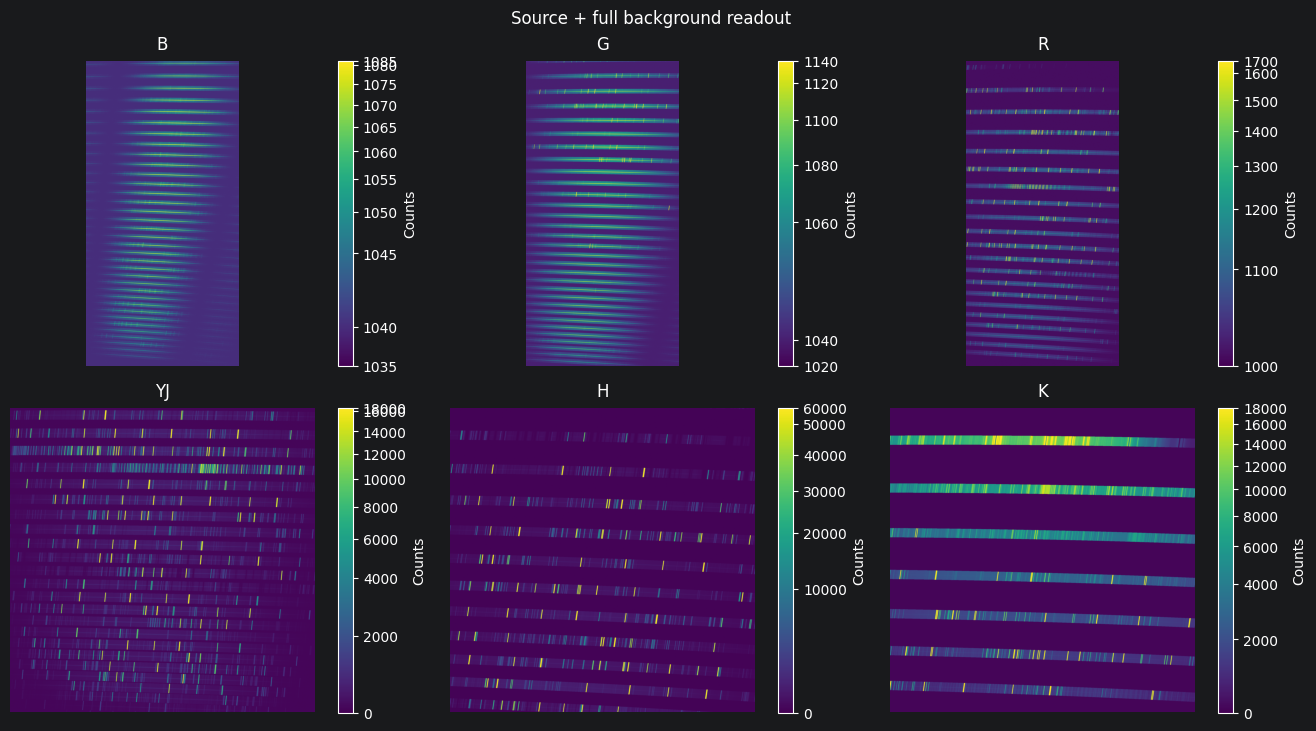

In [26]:
source_readout_products = show_and_save_hdul(
    readouts["source_full_background"],
    label="source_full_background",
    titles=readout_titles,
    output_dir=output_dir,
    save=True,
    figure_title="Source + full background readout",
    hdul_view=READOUT_VIEW,
)


In [27]:
source_readout_products["directory"]

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/science_validation_outputs/readouts/source_full_background')

In [47]:
readouts["empty_full_background"] = observe_readout(None, None)
# readouts["source_no_sky"] = observe_readout(source_to_observe, ["sky"])
readouts["source_no_sky_lines"] = observe_readout(source_to_observe, ["sky_lines"])
readouts["empty_no_sky_lines"] = observe_readout(None, ["sky_lines"])
# readouts["empty_no_sky_continuum"] = observe_readout(None, ["sky_continuum"])
if cmd["!INST.include_diffuse_emmisivity"]:
    readouts["source_no_diffuse_emissivity"] = observe_readout(source_to_observe, ["diffuse_emissivity"])


py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,6654868.000000,8581227.000000,-1926359.000000,103.000000,-20.000000,103.000000,2458018
1,G,4096x2048,14297889.000000,18746333.000000,-4448444.000000,378.000000,-410.000000,410.000000,3138453
2,R,4096x2048,14282006.000000,20698514.000000,-6416508.000000,734.000000,-616.000000,734.000000,2409113
3,YJ,2048x2048,14273047.000000,28691867.000000,-14418820.000000,1649.000000,-1717.000000,1717.000000,2671741
4,H,2048x2048,9334883.000000,25353564.000000,-16018681.000000,4157.000000,-3368.000000,4157.000000,1306454
5,K,2048x2048,7341053.000000,30936422.000000,-23595369.000000,2413.000000,-2150.000000,2413.000000,861513


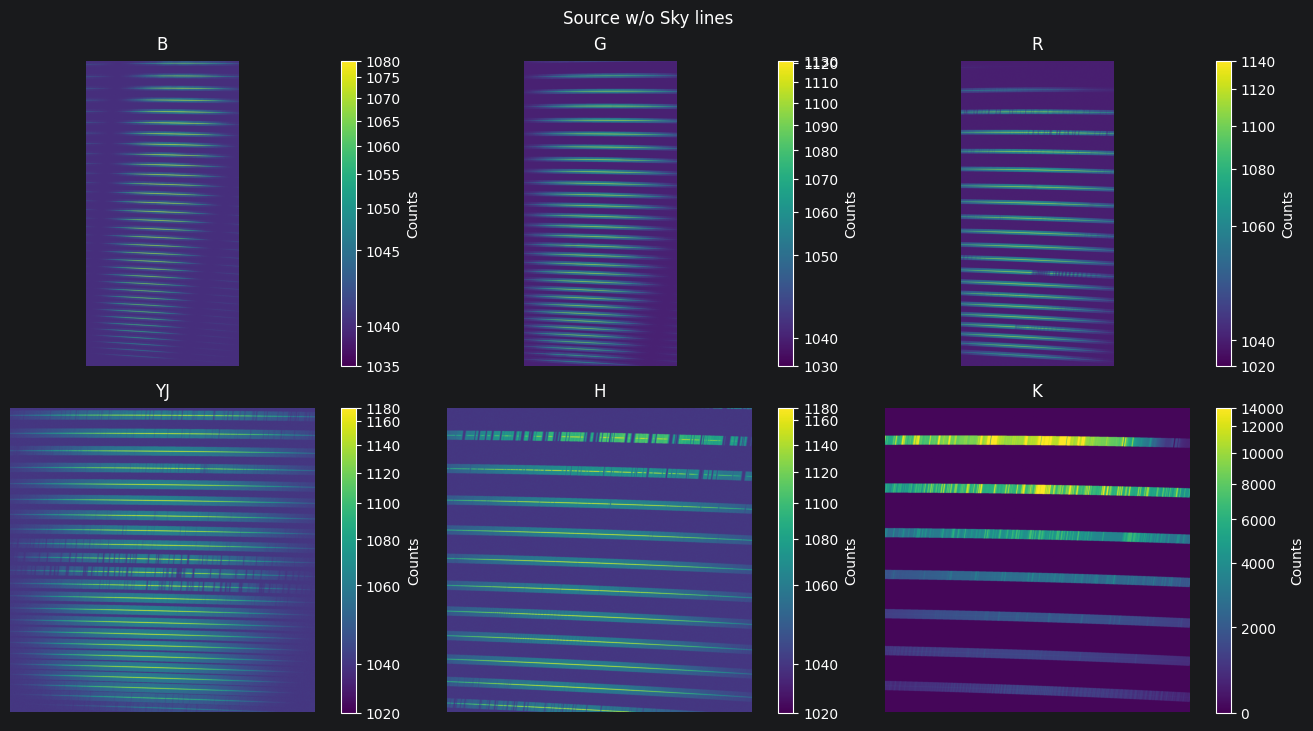

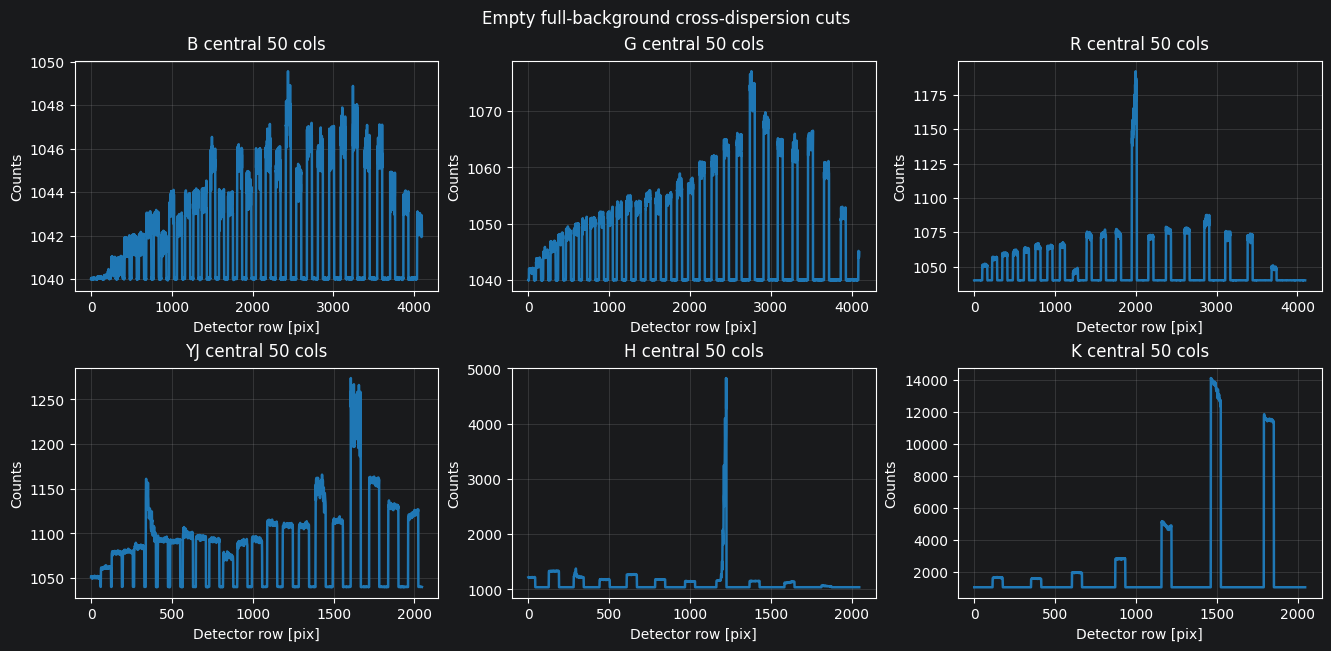

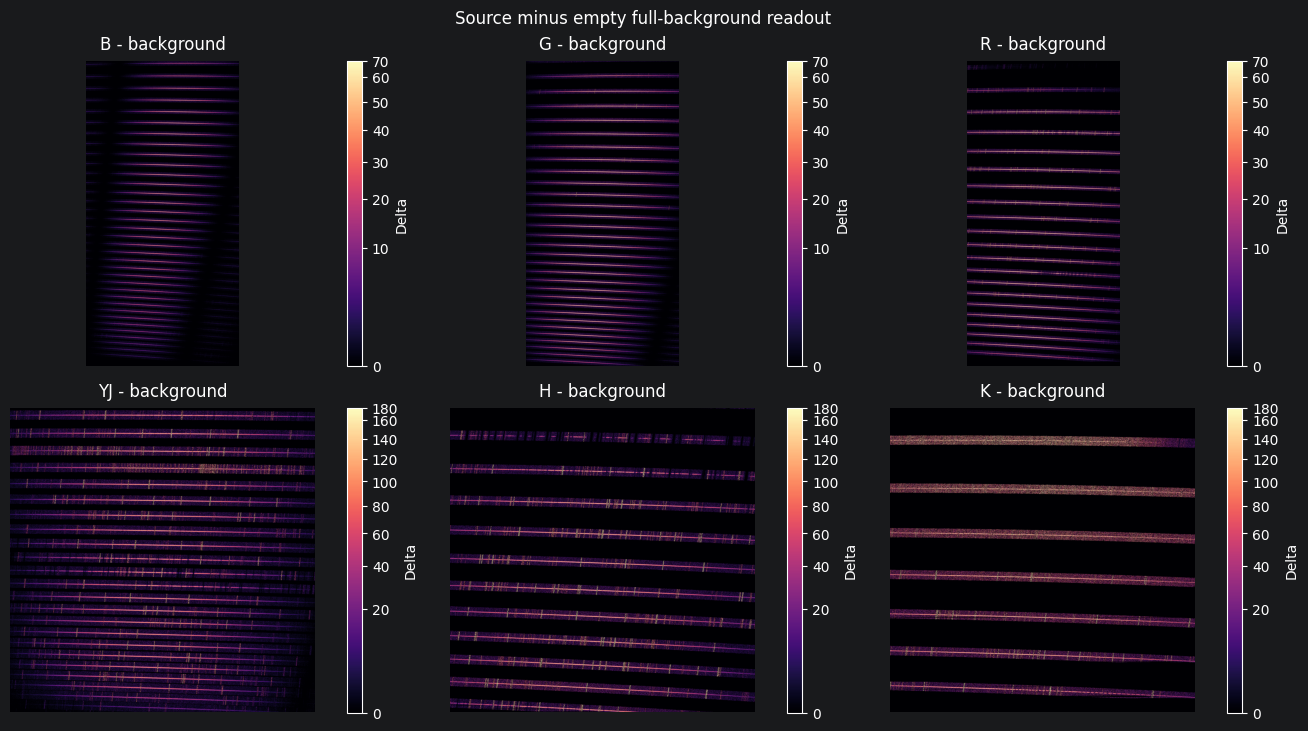

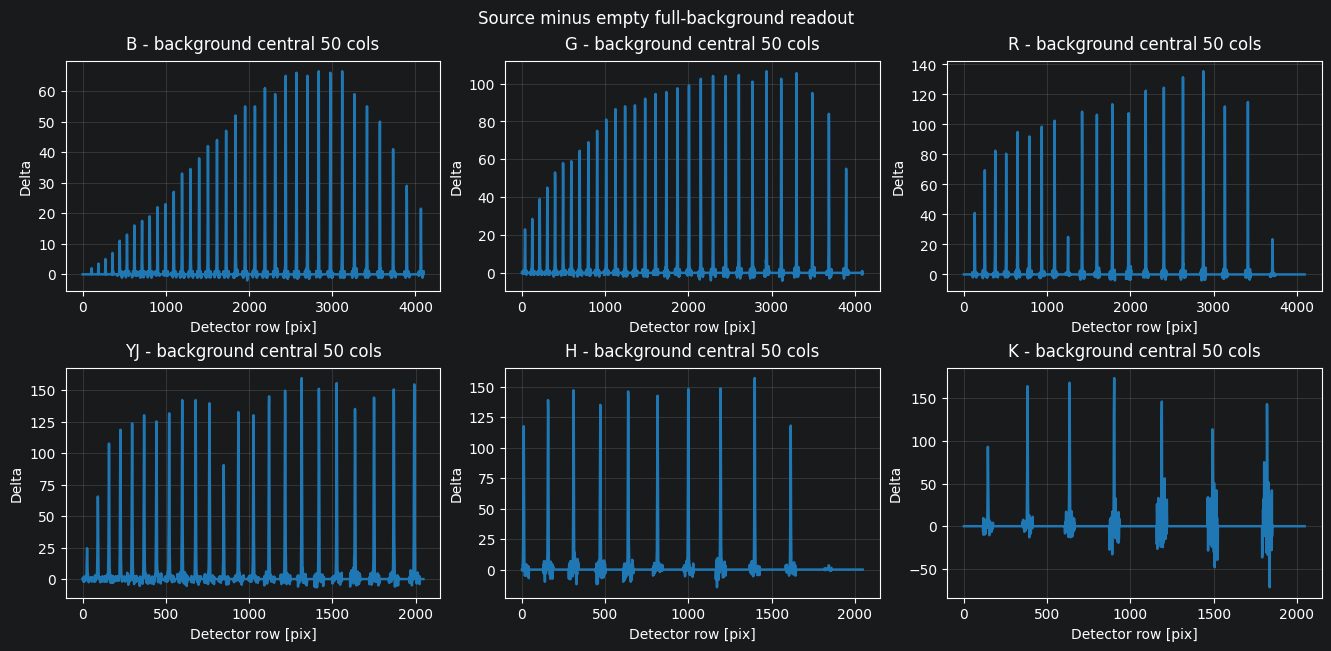

In [48]:
source_no_sky_products = show_and_save_hdul(
    readouts["source_no_sky_lines"],
    label="source_no_sky_lines",
    titles=readout_titles,
    show_hdul=True,
    show_cross_dispersion=False,
    save=False,
    figure_title="Source w/o Sky lines",
    hdul_view=READOUT_VIEW,
)

background_cut_products = show_and_save_hdul(
    readouts["empty_full_background"],
    label="empty_full_background",
    titles=readout_titles,
    show_hdul=False,
    show_cross_dispersion=True,
    save=False,
    figure_title="Empty full-background cross-dispersion cuts",
    hdul_view=BACKGROUND_VIEW,
    cross_dispersion_ylabel="Counts",
)

source_minus_empty = readout_delta_summary_table(readouts["source_full_background"], readouts["empty_full_background"], titles=readout_titles)
display_frame(source_minus_empty)
source_minus_empty_products = show_and_save_hdul(
    readouts["source_full_background"],
    label="source_minus_empty",
    titles=readout_titles,
    reference_hdul=readouts["empty_full_background"],
    output_dir=output_dir,
    show_hdul=False,
    show_delta=True,
    show_cross_dispersion=True,
    save=True,
    figure_title="Source minus empty full-background readout",
    delta_view=DELTA_VIEW,
    delta_title_suffix=" - background",
    cross_dispersion_ylabel="Delta",
)


source+sky line


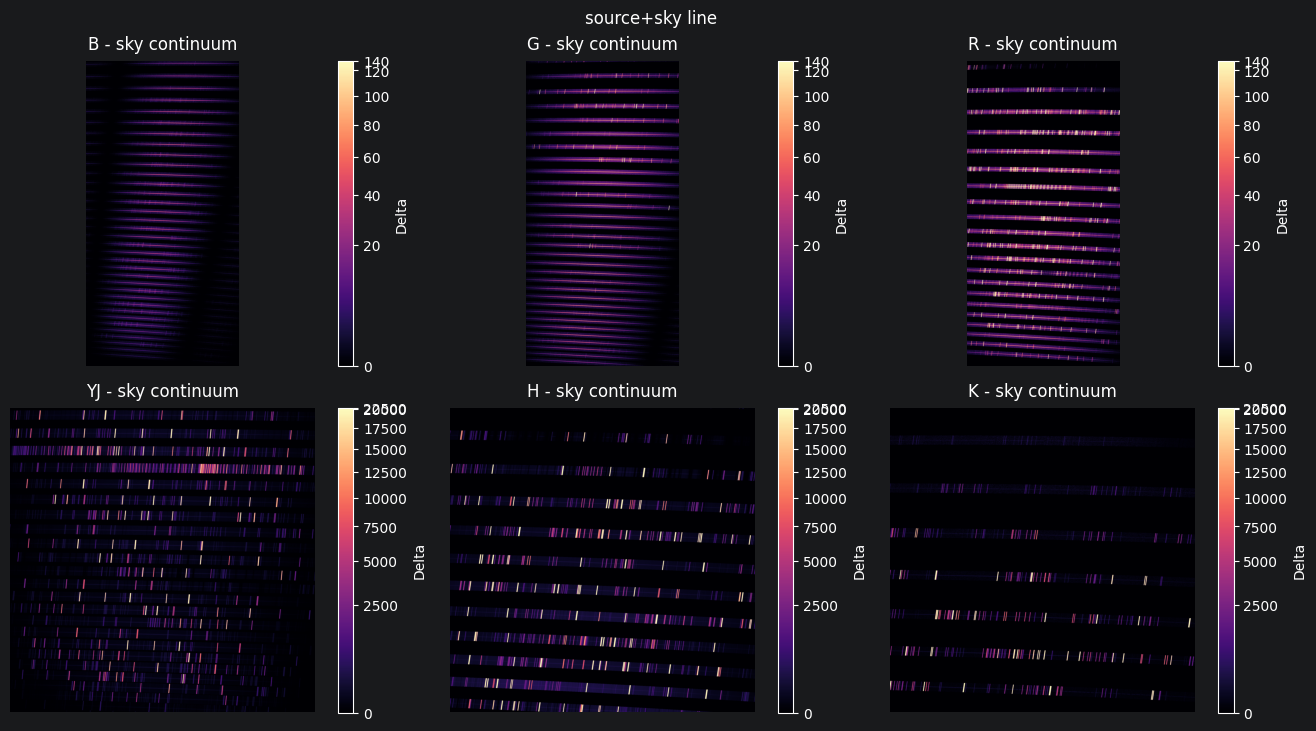

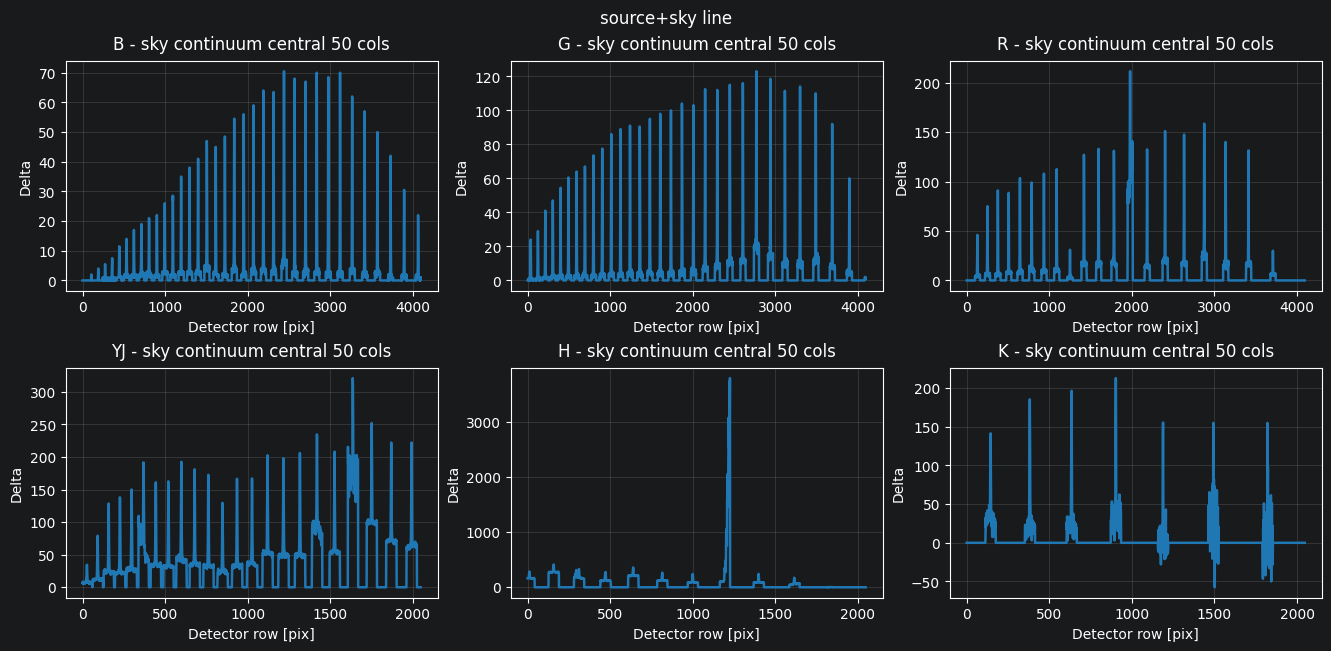

In [49]:
scenario_deltas = OrderedDict([
    ("source+sky line", (readouts["source_full_background"], readouts["empty_no_sky_lines"], " - sky continuum")),
    # ("sky continuum contribution", (readouts["source_full_background"], readouts["empty_no_sky_continuum"], " - sky lines")),
])
if cmd["!INST.include_diffuse_emmisivity"]:
    scenario_deltas["diffuse emissivity contribution"] = (readouts["source_full_background"], readouts["source_no_diffuse_emissivity"], " - no diffuse")
for label, (signal, reference, suffix) in scenario_deltas.items():
    print(label)
    show_and_save_hdul(
        signal,
        reference_hdul=reference,
        label=label.replace(" ", "_"),
        titles=readout_titles,
        show_hdul=False,
        show_delta=True,
        show_cross_dispersion=True,
        save=False,
        figure_title=label,
        delta_view=DELTA_VIEW,
        delta_title_suffix=suffix,
        cross_dispersion_ylabel="Delta",
    )


## Per-Pixel And Resolution-Element S/N Diagnostics

The S/N images use `source_full_background - empty_full_background` for the source signal. The denominator uses positive source counts, a sky/background estimate from the empty readout after subtracting bias and detector additive terms, and the full detector noise term from the detector budget. The trace table samples those S/N images at predicted trace centers, keeps a tiny local peak check for pixel-registration tolerance, and reports compact order/channel ranges.


In [50]:
def readout_image(channel_hdul):
    if isinstance(channel_hdul, np.ndarray):
        return np.asarray(channel_hdul, dtype=float)
    if hasattr(channel_hdul, "data") and channel_hdul.data is not None:
        return np.asarray(channel_hdul.data, dtype=float)
    image_hdu = channel_hdul[1]
    return np.asarray(image_hdu.data, dtype=float)

def budget_value(row, table, column, default=0.0):
    return float(row[column]) if column in table.colnames else float(default)

def snr_images_from_readouts(source_hdul, empty_hdul, budget_table, titles):
    budget_by_channel = {str(row["channel"]): row for row in budget_table}
    signal_images = []
    background_images = []
    snr_images = []
    for title, source_hdu, empty_hdu in zip(titles, source_hdul, empty_hdul, strict=True):
        row = budget_by_channel[title]
        source_image = readout_image(source_hdu)
        empty_image = readout_image(empty_hdu)
        signal = source_image - empty_image
        signal_pos = np.clip(signal, 0, None)
        bias = budget_value(row, budget_table, "bias_e_pix")
        additive = budget_value(row, budget_table, "additive_signal_e_pix")
        total_noise = budget_value(row, budget_table, "total_noise_e_rms",  default=budget_value(row, budget_table, "read_noise_e_rms"))
        background = np.clip(empty_image - bias - additive, 0, None)
        variance = signal_pos + background + total_noise**2
        snr = np.divide(signal_pos, np.sqrt(variance), out=np.zeros_like(signal_pos), where=variance > 0)
        signal_images.append(signal)
        background_images.append(background)
        snr_images.append(snr)
    return signal_images, background_images, snr_images

def resolution_footprint_from_summary(summary_table):
    rows = []
    display_rows = []
    for row in summary_table:
        channel = str(row["channel"])
        spectral_min = float(row["typical_spectral_element_width_min_pix"])
        spectral_median = float(row["typical_spectral_element_width_median_pix"])
        spectral_max = float(row["typical_spectral_element_width_max_pix"])
        spatial_min = float(row["spatial_fwhm_min_pix"])
        spatial_median = float(row["spatial_fwhm_median_pix"])
        spatial_max = float(row["spatial_fwhm_max_pix"])
        resel_min = float(row["resel_footprint_min_pix"])
        resel_median = float(row["resel_footprint_median_pix"])
        resel_max = float(row["resel_footprint_max_pix"])
        rows.append({
            "channel": channel,
            "current_slit_arcsec": float(row["active_slit_width_arcsec"]),
            "trace_R_median": float(row["trace_R_median"]),
            "dispersion_median_nm_pix": float(row["dispersion_median_nm_pix"]),
            "spectral_fwhm_pix": spectral_median,
            "spectral_fwhm_min_pix": spectral_min,
            "spectral_fwhm_max_pix": spectral_max,
            "psf_fwhm_median_arcsec": float(row["seeing_fwhm_median_arcsec"]),
            "pixel_scale_arcsec_pix": float(row["pixel_scale_arcsec_pix"]),
            "spatial_fwhm_pix": spatial_median,
            "spatial_fwhm_min_pix": spatial_min,
            "spatial_fwhm_max_pix": spatial_max,
            "resel_pixels_fwhm": resel_median,
            "resel_pixels_min_fwhm": resel_min,
            "resel_pixels_max_fwhm": resel_max,
        })
        display_rows.append({
            "channel": channel,
            "slit [arcsec]": float(row["active_slit_width_arcsec"]),
            "R": float(row["trace_R_median"]),
            "disp [nm/pix]": float(row["dispersion_median_nm_pix"]),
            "spec pix": compact_range(spectral_min, spectral_max, 1),
            "seeing [arcsec]": float(row["seeing_fwhm_median_arcsec"]),
            "spat pix": compact_range(spatial_min, spatial_max, 1),
            "resel pix": compact_range(resel_min, resel_max, 1),
            "sqrt pix": float(np.sqrt(resel_median)),
        })
    return Table(rows=rows), display_rows

def gaussian_spatial_effective_pixels(spatial_fwhm_pix):
    sigma = float(spatial_fwhm_pix) / 2.354820045
    box_width = float(spatial_fwhm_pix)
    if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(box_width) or box_width <= 0:
        return np.nan
    gaussian_area_in_box = np.sqrt(2*np.pi) * sigma * erf(box_width / (2*np.sqrt(2)*sigma))
    return gaussian_area_in_box**2 / box_width

def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]

def finite_median(values):
    values = finite_values(values)
    return float(np.nanmedian(values)) if values.size else np.nan

def finite_percentile(values, percentile):
    values = finite_values(values)
    return float(np.nanpercentile(values, percentile)) if values.size else np.nan

def finite_min(values):
    values = finite_values(values)
    return float(np.nanmin(values)) if values.size else np.nan

def finite_max(values):
    values = finite_values(values)
    return float(np.nanmax(values)) if values.size else np.nan

def finite_range_text(values, digits=1):
    values = finite_values(values)
    if not values.size:
        return "--"
    return compact_range(float(np.nanmin(values)), float(np.nanmax(values)), digits)

def trace_peak_resel_snr_by_order(trace_samples, snr_images, titles, local_radius=1):
    snr_by_channel = {title: image for title, image in zip(titles, snr_images, strict=True)}
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    trace_values = np.asarray(trace_samples["trace_id"], dtype=str)
    rows = []
    for channel in titles:
        image = snr_by_channel[channel]
        channel_mask = channel_values == channel
        for trace_id in sorted(set(trace_values[channel_mask]), key=lambda x: int(x.partition('_')[2])):
            samples = trace_samples[channel_mask & (trace_values == trace_id)]
            center_values = []
            local_peak_values = []
            for sample in samples:
                x = int(np.rint(float(sample["detector_x_pix"])))
                y = int(np.rint(float(sample["detector_y_pix"])))
                if y < 0 or y >= image.shape[0] or x < 0 or x >= image.shape[1]:
                    continue
                center_values.append(float(image[y, x]))
                y0 = max(0, y - local_radius)
                y1 = min(image.shape[0], y + local_radius + 1)
                x0 = max(0, x - local_radius)
                x1 = min(image.shape[1], x + local_radius + 1)
                local_peak_values.append(float(np.nanmax(image[y0:y1, x0:x1])))
            spectral_pix = finite_median(samples["spectral_element_width_pix"])
            spatial_pix = finite_median(samples["spatial_fwhm_pix"])
            spatial_eff = gaussian_spatial_effective_pixels(spatial_pix)
            eff_pixels = spectral_pix * spatial_eff
            peak_median = finite_median(local_peak_values)
            rows.append({
                "channel": channel,
                "trace_id": trace_id,
                "samples": len(local_peak_values),
                "wave_min_nm": finite_percentile(samples["wave_nm"], 0),
                "wave_max_nm": finite_percentile(samples["wave_nm"], 100),
                "wave_mid_nm": finite_median(samples["wave_nm"]),
                "center_pixel_snr_median": finite_median(center_values),
                "peak_pixel_snr_median": peak_median,
                "peak_pixel_snr_p90": finite_percentile(local_peak_values, 90),
                "spectral_width_pix": spectral_pix,
                "spatial_fwhm_pix": spatial_pix,
                "spatial_eff_pix": spatial_eff,
                "eff_pixels": eff_pixels,
                "resel_snr_median": peak_median * np.sqrt(eff_pixels),
            })
    return Table(rows=rows)

def trace_peak_resel_snr_summary(order_table, titles=None):
    rows = []
    display_rows = []
    if len(order_table) == 0:
        return Table(rows=rows), display_rows
    channels = list(titles) if titles is not None else sorted(set(np.asarray(order_table["channel"], dtype=str)))
    order_channels = np.asarray(order_table["channel"], dtype=str)
    for channel in channels:
        orders = order_table[order_channels == channel]
        if len(orders) == 0:
            continue
        wave_min = finite_min(orders["wave_min_nm"])
        wave_max = finite_max(orders["wave_max_nm"])
        eff_values = finite_values(orders["eff_pixels"])
        row = {
            "channel": channel,
            "orders": len(orders),
            "wave_min_nm": wave_min,
            "wave_max_nm": wave_max,
            "pixel_snr_min": finite_min(orders["peak_pixel_snr_median"]),
            "pixel_snr_max": finite_max(orders["peak_pixel_snr_median"]),
            "resel_snr_min": finite_min(orders["resel_snr_median"]),
            "resel_snr_max": finite_max(orders["resel_snr_median"]),
            "p90_pixel_snr_min": finite_min(orders["peak_pixel_snr_p90"]),
            "p90_pixel_snr_max": finite_max(orders["peak_pixel_snr_p90"]),
            "spectral_width_min_pix": finite_min(orders["spectral_width_pix"]),
            "spectral_width_max_pix": finite_max(orders["spectral_width_pix"]),
            "spatial_fwhm_min_pix": finite_min(orders["spatial_fwhm_pix"]),
            "spatial_fwhm_max_pix": finite_max(orders["spatial_fwhm_pix"]),
            "eff_pixels_median": float(np.nanmedian(eff_values)) if eff_values.size else np.nan,
            "eff_pixels_min": float(np.nanmin(eff_values)) if eff_values.size else np.nan,
            "eff_pixels_max": float(np.nanmax(eff_values)) if eff_values.size else np.nan,
        }
        rows.append(row)
        display_rows.append({
            "channel": channel,
            "orders": len(orders),
            "wave [nm]": compact_range(wave_min, wave_max, 0),
            "pix S/N": compact_range(row["pixel_snr_min"], row["pixel_snr_max"], 1),
            "S/N": compact_range(row["resel_snr_min"], row["resel_snr_max"], 1),
            "p90 pix S/N": compact_range(row["p90_pixel_snr_min"], row["p90_pixel_snr_max"], 1),
            "spec pix": compact_range(row["spectral_width_min_pix"], row["spectral_width_max_pix"], 1),
            "spat pix": compact_range(row["spatial_fwhm_min_pix"], row["spatial_fwhm_max_pix"], 1),
            "eff pix": compact_range(row["eff_pixels_min"], row["eff_pixels_max"], 1),
        })
    return Table(rows=rows), display_rows

def image_norm_for_view(data, view):
    from matplotlib.colors import LogNorm, Normalize, PowerNorm, SymLogNorm
    finite = finite_values(data)
    if not finite.size:
        return Normalize(vmin=0, vmax=1)
    clip = view.get("clip", 0.995)
    zero_floor = bool(view.get("zero_floor", False))
    vmin = view.get("vmin")
    vmax = view.get("vmax")
    if vmin is None:
        vmin = 0.0 if zero_floor else float(np.nanmin(finite))
    if vmax is None:
        if clip is None:
            vmax = float(np.nanmax(finite))
        elif float(clip) <= 1:
            vmax = float(np.nanquantile(finite, float(clip)))
        else:
            vmax = float(clip)
    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = vmin + 1.0
    stretch = view.get("stretch", "linear")
    if stretch == "sqrt":
        return PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax, clip=True)
    if stretch == "log":
        positive = finite[finite > 0]
        floor = float(np.nanmin(positive)) if positive.size else 1e-6
        return LogNorm(vmin=max(vmin, floor), vmax=max(vmax, floor * 10))
    if stretch == "symlog":
        linthresh = max((vmax - vmin) * 1e-3, 1e-3)
        return SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
    return Normalize(vmin=vmin, vmax=vmax)

def detector_image_widget(images, titles, view, *, value_label="", title=""):
    try:
        import ipywidgets as widgets
        from IPython.display import clear_output
    except ImportError:
        print("ipywidgets is not available in this kernel.")
        return None
    arrays = [np.asarray(image, dtype=float) for image in images]
    channel = widgets.Dropdown(options=list(titles), value=list(titles)[0], description="channel")
    x_range = widgets.IntRangeSlider(description="x", continuous_update=False, layout=widgets.Layout(width="95%"))
    y_range = widgets.IntRangeSlider(description="y", continuous_update=False, layout=widgets.Layout(width="95%"))
    full_frame = widgets.Button(description="Full frame")
    out = widgets.Output()

    def set_ranges(index):
        ny, nx = arrays[index].shape
        x_range.min = 0
        x_range.max = nx
        x_range.value = (0, nx)
        y_range.min = 0
        y_range.max = ny
        y_range.value = (0, ny)

    def selected_index():
        return list(titles).index(channel.value)

    def redraw(*_):
        index = selected_index()
        data = arrays[index]
        x0, x1 = x_range.value
        y0, y1 = y_range.value
        if x1 <= x0 or y1 <= y0:
            return
        crop = data[y0:y1, x0:x1]
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(7.5, 5.8), constrained_layout=True)
            im = ax.imshow(
                crop,
                origin="lower",
                cmap=view.get("cmap", "viridis"),
                norm=image_norm_for_view(crop, view),
                interpolation=view.get("interpolation", "hanning"),
                resample=True,
                extent=(x0, x1, y0, y1),
                aspect="auto",
            )
            ax.set_title(f"{title} {channel.value}".strip())
            ax.set_xlabel("x [pix]")
            ax.set_ylabel("y [pix]")
            cbar = fig.colorbar(im, ax=ax)
            if value_label:
                cbar.set_label(value_label)
            display(fig)
            plt.close(fig)

    def reset_full_frame(_=None):
        set_ranges(selected_index())
        redraw()

    def channel_changed(change):
        set_ranges(selected_index())
        redraw()

    channel.observe(channel_changed, names="value")
    x_range.observe(redraw, names="value")
    y_range.observe(redraw, names="value")
    full_frame.on_click(reset_full_frame)
    set_ranges(0)
    controls = widgets.VBox([widgets.HBox([channel, full_frame]), x_range, y_range])
    display(widgets.VBox([controls, out]))
    redraw()
    return dict(channel=channel, x_range=x_range, y_range=y_range, output=out)


In [51]:
signal_images, background_images, snr_images = snr_images_from_readouts(
    readouts["source_no_sky_lines"],
    readouts["empty_no_sky_lines"],
    detector_budget,
    readout_titles,
)

resolution_footprint, resolution_display_rows = resolution_footprint_from_summary(trace_resolution_summary)
display_frame(
    resolution_display_rows,
    formats={
        "slit [arcsec]": "{:.2f}",
        "R": "{:.0f}",
        "disp [nm/pix]": "{:.4f}",
        "seeing [arcsec]": "{:.2f}",
        "sqrt pix": "{:.2f}",
    },
)

trace_peak_snr_by_order = trace_peak_resel_snr_by_order(trace_resolution, snr_images, readout_titles)
trace_peak_snr_summary, trace_peak_snr_display = trace_peak_resel_snr_summary(trace_peak_snr_by_order, readout_titles)
print("Trace-peak S/N per resolution element")
display_frame(trace_peak_snr_display)

# b_order_mask = np.asarray(trace_peak_snr_by_order["channel"], dtype=str) == "B"
# if np.any(b_order_mask):
#     print("B orders")
#     display_frame(
#         trace_peak_snr_by_order[b_order_mask],
#         columns=["trace_id", "samples", "wave_mid_nm", "center_pixel_snr_median", "peak_pixel_snr_median", "peak_pixel_snr_p90", "resel_snr_median", "eff_pixels"],
#         rename={
#             "trace_id": "order",
#             "wave_mid_nm": "wave [nm]",
#             "center_pixel_snr_median": "center pix S/N",
#             "peak_pixel_snr_median": "pix S/N",
#             "peak_pixel_snr_p90": "p90 pix S/N",
#             "resel_snr_median": "S/N",
#             "eff_pixels": "eff pix",
#         },
#         formats={
#             "wave [nm]": "{:.0f}",
#             "center pix S/N": "{:.2f}",
#             "pix S/N": "{:.2f}",
#             "p90 pix S/N": "{:.2f}",
#             "S/N": "{:.2f}",
#             "eff pix": "{:.1f}",
#         },
#     )


channel,slit [arcsec],R,disp [nm/pix],spec pix,seeing [arcsec],spat pix,resel pix,sqrt pix
B,0.70,17779,0.0045,3.6-5.2,0.73,4.5-4.9,17.6-24.0,4.59
G,0.70,17764,0.0065,3.7-5.2,0.68,4.2-4.6,16.6-22.3,4.42
R,0.70,17763,0.0099,3.7-5.2,0.63,3.8-4.2,15.3-20.5,4.24
YJ,0.70,17622,0.0141,3.8-5.1,0.59,3.6-3.9,14.0-19.3,4.09
H,0.70,17591,0.0210,3.7-5.1,0.54,3.4-3.6,13.1-17.5,3.94
K,0.70,17687,0.0282,3.7-5.1,0.51,3.2-3.3,12.5-16.5,3.82


Trace-peak S/N per resolution element


channel,orders,wave [nm],pix S/N,S/N,p90 pix S/N,spec pix,spat pix,eff pix
B,35,306-437,1.4-4.8,5.2-17.7,2.6-8.3,4.5,4.6-4.9,13.4-14.2
G,30,425-656,4.4-7.7,15.9-27.2,6.0-10.1,4.5,4.2-4.6,12.3-13.4
R,21,644-1021,0.0-9.8,0.0-33.2,1.0-11.3,4.5,3.8-4.2,11.3-12.3
YJ,23,949-1346,1.9-9.1,6.3-29.8,4.5-11.9,4.5,3.6-3.9,10.6-11.4
H,11,1471-1871,4.0-10.6,12.5-33.9,7.4-12.4,4.5,3.4-3.6,10.0-10.4
K,7,2027-2474,2.9-6.6,9.0-20.7,4.2-8.8,4.5,3.2-3.3,9.4-9.8


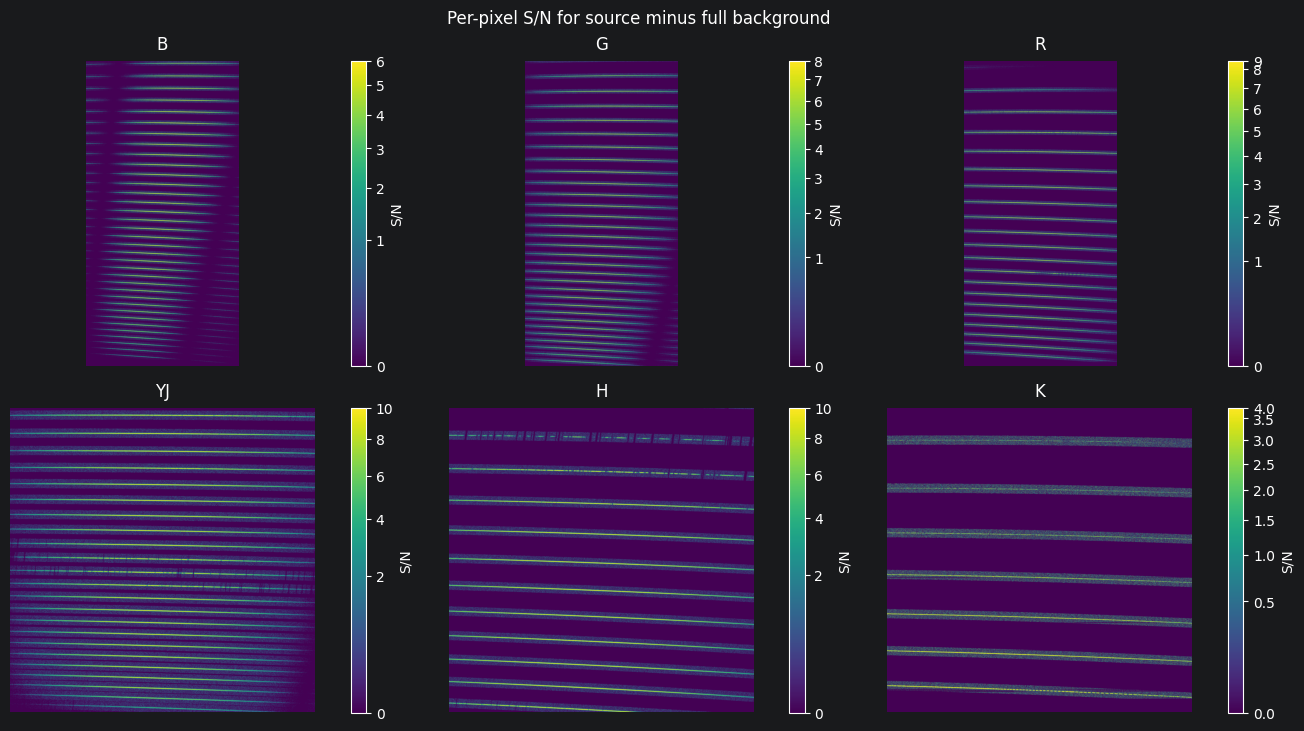

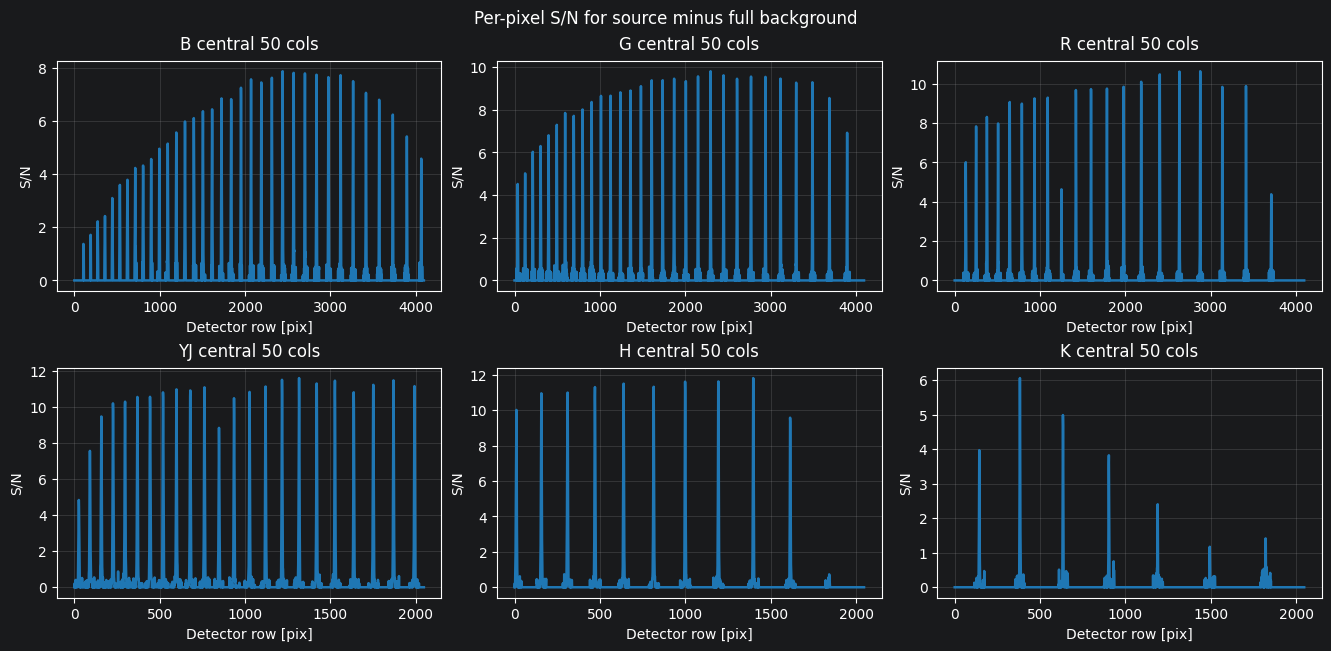

In [52]:
snr_products = show_and_save_hdul(
    snr_images,
    label="source_minus_background_snr_pixel",
    titles=readout_titles,
    output_dir=output_dir,
    show_hdul=True,
    show_cross_dispersion=True,
    save=True,
    figure_title="Per-pixel S/N for source minus full background",
    hdul_view=SNR_VIEW,
    cross_dispersion_ylabel="S/N",
)


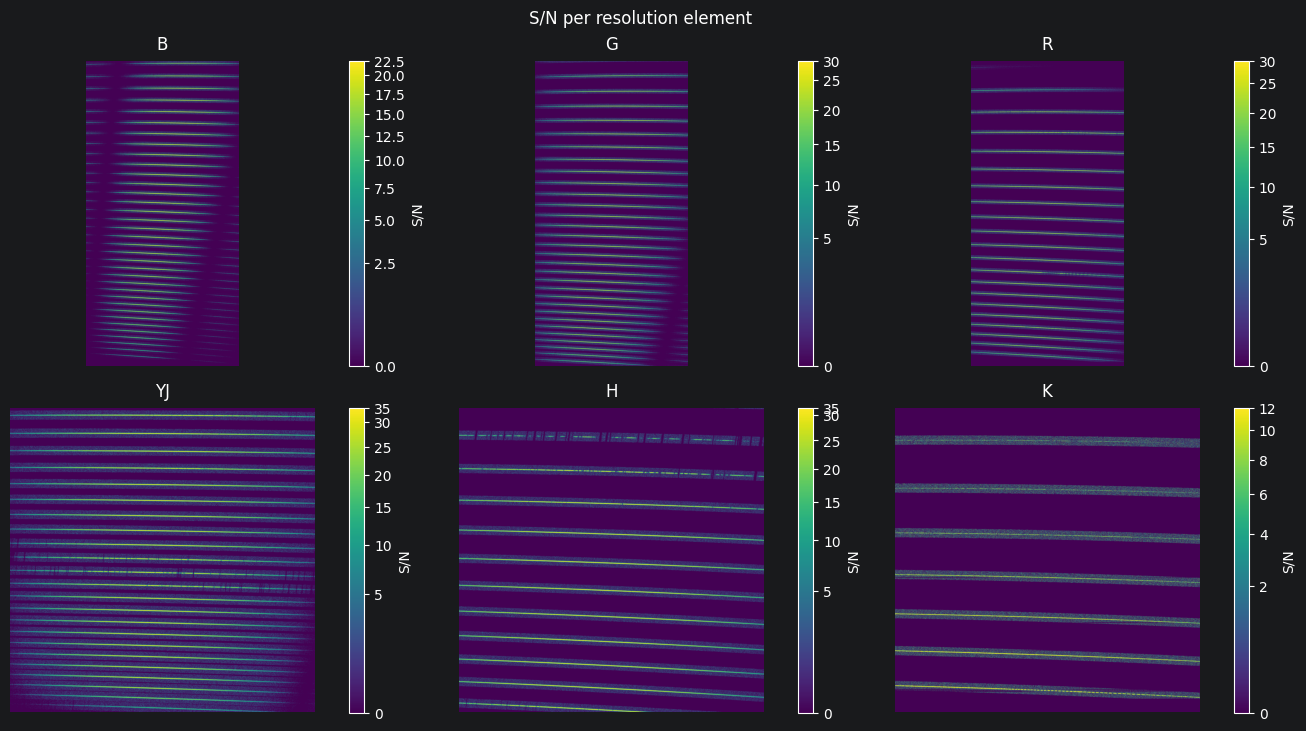

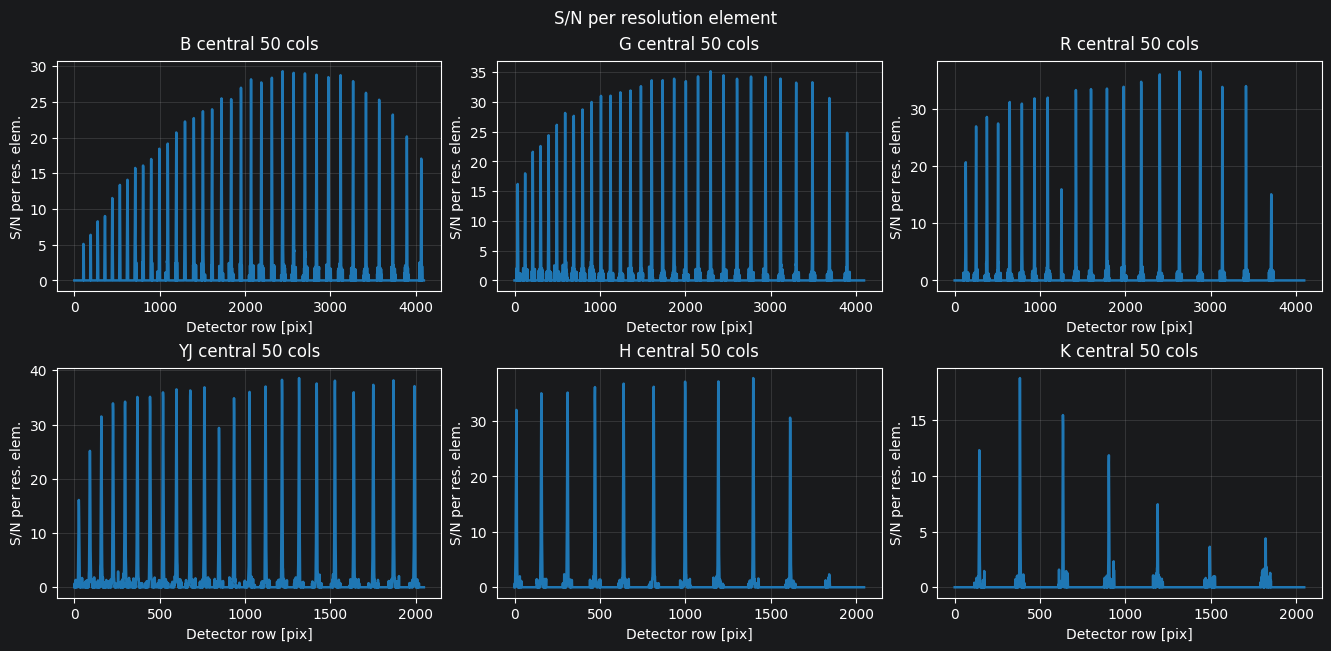

In [53]:
snr_scale_by_channel = {str(row["channel"]): np.sqrt(float(row["eff_pixels_median"])) for row in trace_peak_snr_summary}
resel_snr_images = [snr * snr_scale_by_channel[title] for title, snr in zip(readout_titles, snr_images, strict=True)]

resel_snr_products = show_and_save_hdul(
    resel_snr_images,
    label="source_minus_background_snr_resel",
    titles=readout_titles,
    output_dir=output_dir,
    show_hdul=True,
    show_cross_dispersion=True,
    save=True,
    figure_title="S/N per resolution element",
    hdul_view=SNR_VIEW,
    cross_dispersion_ylabel="S/N per res. elem.",
)

In [54]:
#snr_widget = detector_image_widget(snr_images, readout_titles, SNR_VIEW, value_label="S/N", title="Pixel S/N")

## Trace-Following Zero Point Estimation

This section estimates the one-hour AB magnitude that gives `S/N = 5` in a trace-following extraction. The simulated source magnitude is read from `source_brightness_m_am`, so the calculation remains valid as long as there is sufficient signal in a trace.

The extraction uses the ScopeSim trace centers for every sampled order. For each order, the representative value is taken at the peak of the extracted source signal along that order, rather than at a fixed detector column. This matters because the blaze/source peak shifts with order, most visibly in the B and G channels.

Two spectral apertures are reported. `unbinned` uses the slit-resolution spectral footprint from the trace metadata. `R1000` uses the local trace dispersion and a width `lambda / 1000`. Both modes use a spatial aperture one PSF FWHM tall, centered on the trace. No aperture correction is applied; the reported zero points are for this explicit aperture definition.

For each aperture, the source signal is

`S0 = source_full_background - empty_full_background`,

and the fixed non-source variance term is

`C = background + detector_noise_variance`,

where the background image follows the same convention as the S/N diagnostics above: `empty - bias - additive`, clipped at zero, and the detector variance comes from the detector-budget table. The limiting magnitude is computed with the exact solve

`5 = f S0 / sqrt(f S0 + C)`,

then `m5 = m0 - 2.5 log10(f)`. This keeps source shot noise in the scaling instead of assuming the strictly background-limited approximation.


In [55]:
ZERO_POINT_TARGET_SNR = 5.0
ZERO_POINT_R1000 = 1000.0
ZERO_POINT_SPATIAL_FWHM_SCALE = 1.0


def trace_id_sort_key(trace_id):
    text = str(trace_id)
    prefix, separator, suffix = text.partition("_")
    try:
        number = int(suffix if separator else text)
    except ValueError:
        number = -1
    return prefix, number, text


def pixel_window_bounds(center, width, limit):
    if not np.isfinite(center) or not np.isfinite(width) or int(limit) <= 0:
        return None
    n_pix = max(1, int(np.ceil(float(width))))
    start = int(np.rint(float(center))) - n_pix // 2
    stop = start + n_pix
    if start < 0:
        stop -= start
        start = 0
    if stop > int(limit):
        start -= stop - int(limit)
        stop = int(limit)
    start = max(0, start)
    if stop <= start:
        return None
    return start, stop


def readout_signal_background_images(source_hdul, empty_hdul, budget_table, titles):
    budget_by_channel = {str(row["channel"]): row for row in budget_table}
    products = {}
    for title, source_hdu, empty_hdu in zip(titles, source_hdul, empty_hdul, strict=True):
        row = budget_by_channel[str(title)]
        source_image = readout_image(source_hdu)
        empty_image = readout_image(empty_hdu)
        bias = budget_value(row, budget_table, "bias_e_pix")
        additive = budget_value(row, budget_table, "additive_signal_e_pix")
        detector_noise = budget_value(
            row,
            budget_table,
            "total_noise_e_rms",
            default=budget_value(row, budget_table, "read_noise_e_rms"),
        )
        products[str(title)] = {
            "signal": np.asarray(source_image - empty_image, dtype=float),
            "background": np.clip(np.asarray(empty_image - bias - additive, dtype=float), 0, None),
            "detector_noise_e": float(detector_noise),
        }
    return products


def extract_trace_window(signal_image, background_image, sample, spectral_width_pix, spatial_width_pix, detector_noise_e):
    y_limit, x_limit = signal_image.shape
    x_bounds = pixel_window_bounds(float(sample["detector_x_pix"]), spectral_width_pix, x_limit)
    y_bounds = pixel_window_bounds(float(sample["detector_y_pix"]), spatial_width_pix, y_limit)
    if x_bounds is None or y_bounds is None:
        return None
    x0, x1 = x_bounds
    y0, y1 = y_bounds
    signal_cut = signal_image[y0:y1, x0:x1]
    background_cut = background_image[y0:y1, x0:x1]
    n_pix = int(signal_cut.size)
    if n_pix <= 0:
        return None
    signal_e = float(np.nansum(signal_cut))
    background_e = float(np.nansum(background_cut))
    detector_var_e = float(n_pix * detector_noise_e**2)
    fixed_variance_e = max(background_e, 0.0) + detector_var_e
    variance_at_input = max(signal_e, 0.0) + fixed_variance_e
    snr_at_input = signal_e / np.sqrt(variance_at_input) if variance_at_input > 0 else np.nan
    return {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "n_pix": n_pix,
        "signal_e": signal_e,
        "background_e": background_e,
        "detector_var_e": detector_var_e,
        "fixed_variance_e": fixed_variance_e,
        "snr_at_input": float(snr_at_input),
    }


def flux_scale_for_target_snr(source_signal_e, fixed_variance_e, target_snr=ZERO_POINT_TARGET_SNR):
    source_signal_e = float(source_signal_e)
    fixed_variance_e = max(float(fixed_variance_e), 0.0)
    target_snr = float(target_snr)
    if not np.isfinite(source_signal_e) or source_signal_e <= 0 or not np.isfinite(fixed_variance_e):
        return np.nan
    q2 = target_snr**2
    discriminant = (q2 * source_signal_e)**2 + 4 * source_signal_e**2 * q2 * fixed_variance_e
    return float((q2 * source_signal_e + np.sqrt(discriminant)) / (2 * source_signal_e**2))


def limiting_abmag_for_target_snr(input_abmag, source_signal_e, fixed_variance_e, target_snr=ZERO_POINT_TARGET_SNR):
    scale = flux_scale_for_target_snr(source_signal_e, fixed_variance_e, target_snr=target_snr)
    if not np.isfinite(scale) or scale <= 0:
        return np.nan
    return float(input_abmag - 2.5 * np.log10(scale))


def spectral_width_for_mode(sample, mode, target_R=ZERO_POINT_R1000):
    if mode in {"unbinned", "native"}:
        return float(sample["spectral_element_width_pix"]), float(sample["resolving_power_R"])
    if mode == "R1000":
        dispersion = float(sample["dispersion_nm_pix"])
        wave_nm_value = float(sample["wave_nm"])
        width = wave_nm_value / (float(target_R) * dispersion) if dispersion > 0 else np.nan
        return float(width), float(target_R)
    raise ValueError(f"Unknown zero-point extraction mode {mode!r}.")


def trace_zero_point_ladder_table(
    source_hdul,
    empty_hdul,
    budget_table,
    trace_samples,
    titles,
    *,
    input_abmag,
    case_label,
    modes=("unbinned", "R1000"),
    target_snr=ZERO_POINT_TARGET_SNR,
    target_R=ZERO_POINT_R1000,
    spatial_fwhm_scale=ZERO_POINT_SPATIAL_FWHM_SCALE,
):
    image_products = readout_signal_background_images(source_hdul, empty_hdul, budget_table, titles)
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    rows = []
    for channel in titles:
        channel = str(channel)
        channel_samples = trace_samples[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            order_samples = channel_samples[trace_values == trace_id]
            sample_order = np.argsort(np.asarray(order_samples["wave_nm"], dtype=float))
            for sample in order_samples[sample_order]:
                spatial_width_pix = float(sample["spatial_fwhm_pix"]) * float(spatial_fwhm_scale)
                for mode in modes:
                    spectral_width_pix, extraction_R = spectral_width_for_mode(sample, mode, target_R=target_R)
                    extraction = extract_trace_window(
                        image_products[channel]["signal"],
                        image_products[channel]["background"],
                        sample,
                        spectral_width_pix,
                        spatial_width_pix,
                        image_products[channel]["detector_noise_e"],
                    )
                    if extraction is None:
                        continue
                    m5_ab = limiting_abmag_for_target_snr(
                        input_abmag,
                        extraction["signal_e"],
                        extraction["fixed_variance_e"],
                        target_snr=target_snr,
                    )
                    rows.append({
                        "case": str(case_label),
                        "channel": channel,
                        "mode": str(mode),
                        "trace_id": str(trace_id),
                        "sample_index": int(sample["sample_index"]),
                        "wave_nm": float(sample["wave_nm"]),
                        "detector_x_pix": float(sample["detector_x_pix"]),
                        "detector_y_pix": float(sample["detector_y_pix"]),
                        "extraction_R": extraction_R,
                        "spectral_width_pix": float(spectral_width_pix),
                        "spatial_width_pix": float(spatial_width_pix),
                        "n_pix": int(extraction["n_pix"]),
                        "signal_e": float(extraction["signal_e"]),
                        "background_e": float(extraction["background_e"]),
                        "detector_var_e": float(extraction["detector_var_e"]),
                        "fixed_variance_e": float(extraction["fixed_variance_e"]),
                        "snr_at_input": float(extraction["snr_at_input"]),
                        "m5_ab": float(m5_ab),
                        "input_abmag": float(input_abmag),
                        "target_snr": float(target_snr),
                    })
    return Table(rows=rows)


def representative_zero_point_order_table(ladder_table):
    rows = []
    if len(ladder_table) == 0:
        return Table(rows=rows)
    case_values = np.asarray(ladder_table["case"], dtype=str)
    channel_values = np.asarray(ladder_table["channel"], dtype=str)
    mode_values = np.asarray(ladder_table["mode"], dtype=str)
    trace_values = np.asarray(ladder_table["trace_id"], dtype=str)
    for case in list(dict.fromkeys(case_values)):
        for channel in list(dict.fromkeys(channel_values[case_values == case])):
            channel_mask = (case_values == case) & (channel_values == channel)
            for mode in list(dict.fromkeys(mode_values[channel_mask])):
                mode_mask = channel_mask & (mode_values == mode)
                for trace_id in sorted(set(trace_values[mode_mask]), key=trace_id_sort_key):
                    order_rows = ladder_table[mode_mask & (trace_values == trace_id)]
                    source_signal = np.asarray(order_rows["signal_e"], dtype=float)
                    rank = np.where(np.isfinite(source_signal), source_signal, -np.inf)
                    if not rank.size:
                        continue
                    row = order_rows[int(np.argmax(rank))]
                    rows.append({name: row[name] for name in ladder_table.colnames})
    return Table(rows=rows)


def order_label(row):
    if row is None:
        return "--"
    return f"{row['trace_id']} {float(row['wave_nm']):.0f} nm"


def zero_point_summary_display_table(order_table, titles=None):
    if len(order_table) == 0:
        return []
    rows = []
    case_values = np.asarray(order_table["case"], dtype=str)
    channel_values = np.asarray(order_table["channel"], dtype=str)
    mode_values = np.asarray(order_table["mode"], dtype=str)
    case_order = list(dict.fromkeys(case_values))
    channel_order = list(titles) if titles is not None else list(dict.fromkeys(channel_values))
    mode_order = [mode for mode in ("unbinned", "R1000", "native") if mode in set(mode_values)]
    for case in case_order:
        for channel in channel_order:
            for mode in mode_order:
                group = order_table[(case_values == case) & (channel_values == channel) & (mode_values == mode)]
                if len(group) == 0:
                    continue
                snr_values = np.asarray(group["snr_at_input"], dtype=float)
                m5_values = np.asarray(group["m5_ab"], dtype=float)
                finite_m5 = np.isfinite(m5_values)
                finite_snr = np.isfinite(snr_values)
                valid_group = group[finite_m5]
                valid_m5 = m5_values[finite_m5]
                worst = median_order = best = None
                median_m5 = np.nan
                if valid_m5.size:
                    worst = valid_group[int(np.nanargmin(valid_m5))]
                    best = valid_group[int(np.nanargmax(valid_m5))]
                    median_m5 = float(np.nanmedian(valid_m5))
                    median_order = valid_group[int(np.nanargmin(np.abs(valid_m5 - median_m5)))]
                rows.append({
                    "case": case,
                    "ch": channel,
                    "mode": mode,
                    "N": len(group),
                    "S/N": finite_range_text(snr_values[finite_snr], 1),
                    "med_S/N": float(np.nanmedian(snr_values[finite_snr])) if np.any(finite_snr) else np.nan,
                    "mAB5": finite_range_text(valid_m5, 1),
                    "med_mAB5": median_m5,
                    "worst": order_label(worst),
                    "med_order": order_label(median_order),
                    "best": order_label(best),
                })
    return rows


def plot_zero_point_ladder(ladder_table, order_table=None, *, case_label=None, titles=None, value="m5_ab", ylabel="mAB for S/N=5"):
    data = ladder_table.to_pandas()
    if case_label is not None:
        data = data[data["case"] == case_label]
    if data.empty:
        raise ValueError("No zero-point ladder rows to plot.")
    peak_data = None
    if order_table is not None and len(order_table) > 0:
        peak_data = order_table.to_pandas()
        if case_label is not None:
            peak_data = peak_data[peak_data["case"] == case_label]
    channels = list(titles) if titles is not None else list(dict.fromkeys(data["channel"]))
    modes = [mode for mode in ("R1000", "unbinned", "native") if mode in set(data["mode"])]
    colors = {"unbinned": "tab:blue", "native": "tab:blue", "R1000": "tab:orange"}
    alphas = {"unbinned": 0.35, "native": 0.35, "R1000": 0.65}
    finite = data[value].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    y_limits = None
    if finite.size:
        lo, hi = np.nanpercentile(finite, [2, 98])
        pad = max(0.2, 0.08 * (hi - lo))
        y_limits = (lo - pad, hi + pad)
    ncols = 3
    nrows = int(np.ceil(len(channels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.1 * nrows), squeeze=False, constrained_layout=True)
    for ax, channel in zip(axes.flat, channels, strict=False):
        channel_data = data[data["channel"] == channel]
        for mode in modes:
            mode_data = channel_data[channel_data["mode"] == mode]
            for _trace_id, order_rows in mode_data.groupby("trace_id", sort=False):
                order_rows = order_rows.sort_values("wave_nm")
                ax.plot(
                    order_rows["wave_nm"],
                    order_rows[value],
                    lw=0.7,
                    alpha=alphas.get(mode, 0.45),
                    color=colors.get(mode, None),
                )
            if peak_data is not None:
                peaks = peak_data[(peak_data["channel"] == channel) & (peak_data["mode"] == mode)]
                ax.scatter(
                    peaks["wave_nm"],
                    peaks[value],
                    s=12,
                    color=colors.get(mode, None),
                    edgecolor="black",
                    linewidth=0.25,
                    alpha=0.9,
                    label=mode,
                )
            else:
                ax.plot([], [], color=colors.get(mode, None), label=mode)
        ax.set_title(channel)
        ax.set_xlabel("Wavelength [nm]")
        ax.set_ylabel(ylabel)
        if y_limits is not None:
            ax.set_ylim(*y_limits)
        ax.grid(alpha=0.25)
    for ax in axes.flat[len(channels):]:
        ax.axis("off")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    if handles:
        axes.flat[0].legend(handles, labels, frameon=False, loc="best")
    if case_label is not None:
        fig.suptitle(f"Trace-following zero-point ladder: {case_label}")
    return fig, axes


In [56]:
zero_point_input_abmag = float(source_brightness_m_am)
zero_point_case_label = f"{float(cmd_value('!INST.vis_curr_slit')):.2f} arcsec slit"
zero_point_ladder = trace_zero_point_ladder_table(
    readouts["source_full_background"],
    readouts["empty_full_background"],
    detector_budget,
    trace_resolution,
    readout_titles,
    input_abmag=zero_point_input_abmag,
    case_label=zero_point_case_label,
)
zero_point_order_peaks = representative_zero_point_order_table(zero_point_ladder)
zero_point_summary_display = zero_point_summary_display_table(zero_point_order_peaks, readout_titles)
print(f"Trace-following zero-point estimate from m_AB={zero_point_input_abmag:.1f}; target S/N={ZERO_POINT_TARGET_SNR:.1f}")
display_frame(
    zero_point_summary_display,
    formats={"med_S/N": "{:.1f}", "med_mAB5": "{:.1f}"},
)


Trace-following zero-point estimate from m_AB=20.0; target S/N=5.0


case,ch,mode,N,S/N,med_S/N,mAB5,med_mAB5,worst,med_order,best
0.70 arcsec slit,B,unbinned,35,9.7-34.9,29.6,21.2-23.2,22.8,b_118 309 nm,b_103 354 nm,b_92 396 nm
0.70 arcsec slit,B,R1000,35,31.5-135.6,110.1,22.8-24.8,24.4,b_118 309 nm,b_103 354 nm,b_92 396 nm
0.70 arcsec slit,G,unbinned,30,10.1-40.9,37.9,20.8-23.2,23.0,g_58 630 nm,g_68 535 nm,g_76 479 nm
0.70 arcsec slit,G,R1000,30,87.0-155.7,147.1,24.1-24.7,24.5,g_56 649 nm,g_70 520 nm,g_74 492 nm
0.70 arcsec slit,R,unbinned,21,1.8-41.9,36.2,18.8-23.0,22.8,r_36 995 nm,r_38 957 nm,r_40 911 nm
0.70 arcsec slit,R,R1000,21,5.7-158.9,134.5,20.1-24.5,24.1,r_36 994 nm,r_45 809 nm,r_40 911 nm
0.70 arcsec slit,YJ,unbinned,23,2.6-41.3,17.1,19.3-22.9,21.4,yj_58 1308 nm,yj_71 1070 nm,yj_72 1054 nm
0.70 arcsec slit,YJ,R1000,23,22.3-153.5,80.3,21.6-24.3,23.2,yj_58 1308 nm,yj_71 1069 nm,yj_72 1054 nm
0.70 arcsec slit,H,unbinned,11,1.4-34.5,3.4,18.6-22.4,19.6,h_43 1765 nm,h_45 1690 nm,h_51 1483 nm
0.70 arcsec slit,H,R1000,11,9.7-74.6,19.3,20.7-23.0,21.5,h_48 1584 nm,h_50 1518 nm,h_44 1723 nm


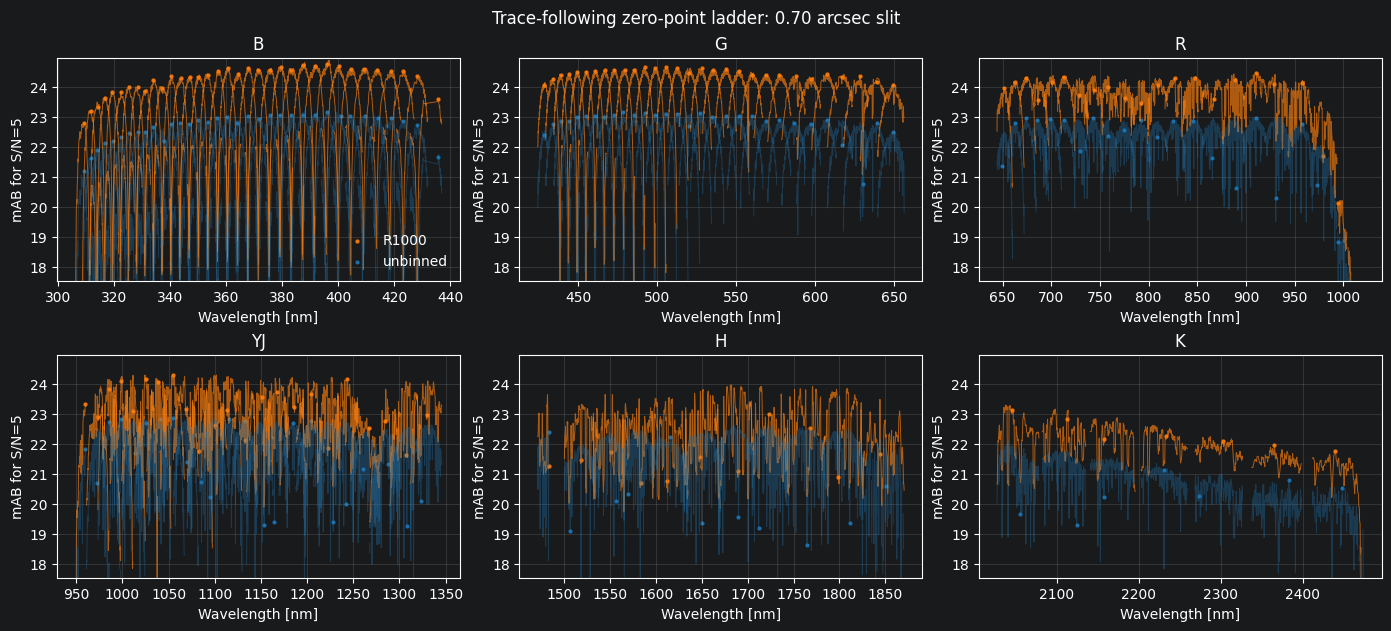

In [57]:
fig, axes = plot_zero_point_ladder(
    zero_point_ladder,
    zero_point_order_peaks,
    case_label=zero_point_case_label,
    titles=readout_titles,
)
display(fig)
plt.close(fig)


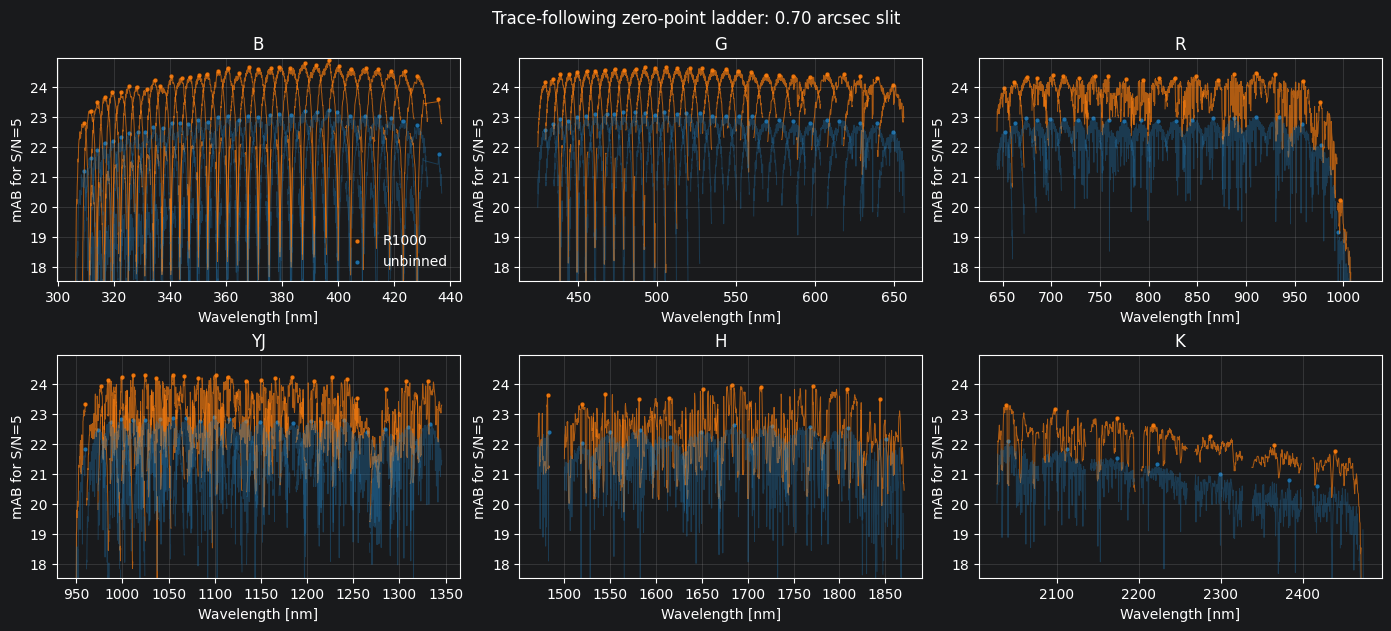

In [58]:
def representative_zero_point_order_table_by_column(ladder_table, rank_column="m5_ab"):
    rows = []
    case_values = np.asarray(ladder_table["case"], dtype=str)
    channel_values = np.asarray(ladder_table["channel"], dtype=str)
    mode_values = np.asarray(ladder_table["mode"], dtype=str)
    trace_values = np.asarray(ladder_table["trace_id"], dtype=str)

    for case in list(dict.fromkeys(case_values)):
        for channel in list(dict.fromkeys(channel_values[case_values == case])):
            channel_mask = (case_values == case) & (channel_values == channel)
            for mode in list(dict.fromkeys(mode_values[channel_mask])):
                mode_mask = channel_mask & (mode_values == mode)
                for trace_id in sorted(set(trace_values[mode_mask]), key=trace_id_sort_key):
                    order_rows = ladder_table[mode_mask & (trace_values == trace_id)]
                    rank = np.asarray(order_rows[rank_column], dtype=float)
                    rank = np.where(np.isfinite(rank), rank, -np.inf)
                    if rank.size:
                        row = order_rows[int(np.argmax(rank))]
                        rows.append({name: row[name] for name in ladder_table.colnames})
    return Table(rows=rows)


zero_point_order_best_m5 = representative_zero_point_order_table_by_column(
    zero_point_ladder,
    rank_column="m5_ab",
)

fig, axes = plot_zero_point_ladder(
    zero_point_ladder,
    zero_point_order_best_m5,
    case_label=zero_point_case_label,
    titles=readout_titles,
)
display(fig)
plt.close(fig)

case,ch,mode,N,S/N,med_S/N,mAB5,med_mAB5,worst,med_order,best
0.70 arcsec slit,B,unbinned,35,9.4-34.6,28.2,21.1-23.2,22.8,b_118 309 nm,b_103 354 nm,b_92 396 nm
0.70 arcsec slit,B,R1000,35,26.2-120.2,95.3,22.5-24.7,24.3,b_118 308 nm,b_102 356 nm,b_92 395 nm
0.70 arcsec slit,G,unbinned,30,22.8-39.8,36.8,22.5-23.1,22.9,g_85 428 nm,g_83 439 nm,g_72 505 nm
0.70 arcsec slit,G,R1000,30,80.8-139.8,132.7,23.9-24.5,24.3,g_56 648 nm,g_78 466 nm,g_72 505 nm
0.70 arcsec slit,R,unbinned,21,1.6-39.9,38.4,18.7-22.9,22.9,r_36 994 nm,r_43 846 nm,r_39 929 nm
0.70 arcsec slit,R,R1000,21,4.6-145.9,120.1,19.9-24.3,24.0,r_36 994 nm,r_53 686 nm,r_40 910 nm
0.70 arcsec slit,YJ,unbinned,23,16.1-39.8,37.4,21.6-22.8,22.6,yj_57 1330 nm,yj_64 1185 nm,yj_74 1025 nm
0.70 arcsec slit,YJ,R1000,23,43.1-122.8,101.8,22.4-23.9,23.5,yj_60 1263 nm,yj_57 1328 nm,yj_72 1052 nm
0.70 arcsec slit,H,unbinned,11,9.2-38.3,27.9,20.7-22.6,22.1,h_49 1554 nm,h_47 1615 nm,h_44 1723 nm
0.70 arcsec slit,H,R1000,11,17.5-99.9,45.1,21.4-23.5,22.4,h_51 1484 nm,h_44 1721 nm,h_42 1800 nm


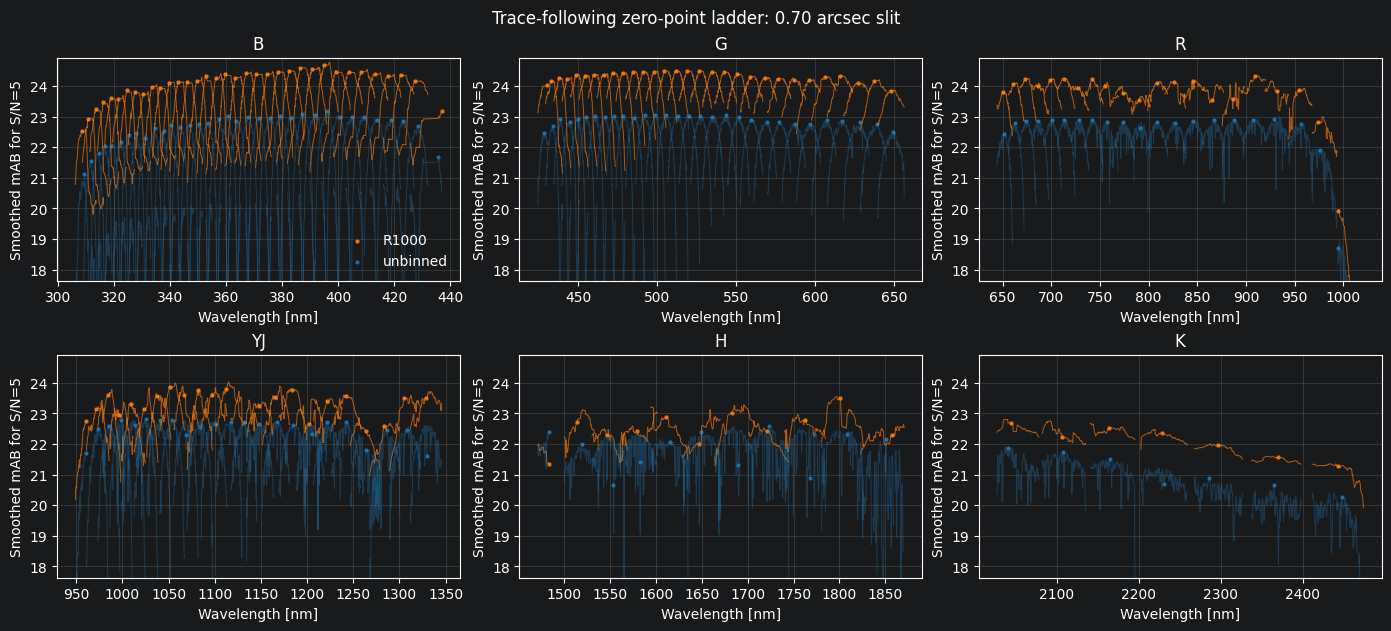

In [59]:
def smoothed_zero_point_ladder_for_report(ladder_table, *, smooth_resels=10, method="median"):
    frame = ladder_table.to_pandas().copy()
    frame["raw_signal_e"] = frame["signal_e"]
    frame["raw_fixed_variance_e"] = frame["fixed_variance_e"]
    frame["raw_snr_at_input"] = frame["snr_at_input"]
    frame["raw_m5_ab"] = frame["m5_ab"]

    smoothed_parts = []
    group_columns = ["case", "channel", "mode", "trace_id"]

    for _keys, group in frame.groupby(group_columns, sort=False):
        group = group.sort_values("wave_nm").copy()
        wave = group["wave_nm"].to_numpy(dtype=float)
        extraction_R = group["extraction_R"].to_numpy(dtype=float)

        spacing_nm = np.nanmedian(np.diff(wave)) if len(wave) > 1 else np.nan
        resel_nm = np.nanmedian(wave / extraction_R)

        if np.isfinite(spacing_nm) and spacing_nm > 0 and np.isfinite(resel_nm) and resel_nm > 0:
            window = int(np.ceil(float(smooth_resels) * resel_nm / spacing_nm))
        else:
            window = 1

        window = max(1, min(window, len(group)))
        if window > 1 and window % 2 == 0:
            window += 1
        min_periods = max(1, window // 3)

        for column in ["signal_e", "fixed_variance_e"]:
            series = pd.Series(group[column].to_numpy(dtype=float))
            rolling = series.rolling(window=window, center=True, min_periods=min_periods)
            if method == "mean":
                group[column] = rolling.mean().to_numpy()
            else:
                group[column] = rolling.median().to_numpy()

        signal = group["signal_e"].to_numpy(dtype=float)
        fixed = group["fixed_variance_e"].to_numpy(dtype=float)
        variance = np.clip(signal, 0, None) + fixed
        group["snr_at_input"] = np.divide(signal, np.sqrt(variance), out=np.full_like(signal, np.nan), where=variance > 0)
        group["m5_ab"] = [
            limiting_abmag_for_target_snr(m0, s, c, target_snr=target)
            for m0, s, c, target in zip(
                group["input_abmag"],
                group["signal_e"],
                group["fixed_variance_e"],
                group["target_snr"],
                strict=True,
            )
        ]
        group["smooth_resels"] = smooth_resels
        group["smooth_window_samples"] = window
        smoothed_parts.append(group)

    return Table.from_pandas(pd.concat(smoothed_parts, ignore_index=True))


zero_point_ladder_smooth10 = smoothed_zero_point_ladder_for_report(
    zero_point_ladder,
    smooth_resels=10,
    method="median",
)

zero_point_order_peaks_smooth10 = representative_zero_point_order_table(
    zero_point_ladder_smooth10
)

zero_point_summary_smooth10 = zero_point_summary_display_table(
    zero_point_order_peaks_smooth10,
    readout_titles,
)

display_frame(
    zero_point_summary_smooth10,
    formats={"med_S/N": "{:.1f}", "med_mAB5": "{:.1f}"},
)

fig, axes = plot_zero_point_ladder(
    zero_point_ladder_smooth10,
    zero_point_order_peaks_smooth10,
    case_label=zero_point_case_label,
    titles=readout_titles,
    ylabel="Smoothed mAB for S/N=5",
)
display(fig)
plt.close(fig)

## Smallest-Slit AO Comparison

This runs the narrowest slit used here, with the same `1800 x 2` exposure. The source readout is run twice, once with natural seeing and once with the AO PSF toggle enabled. The empty background readout is run once for the same narrow slit and reused for both source cases, because the AO PSF changes how source light is concentrated but does not change the detector, sky, or thermal background. The extraction aperture and zero-point calculation are still recomputed for each AO state because the PSF footprint, and therefore the number of pixels entrained, changes.

The first compact table preserves the trace-peak S/N diagnostic used above. The zero-point summary that follows uses the same exact-solve trace-following extraction as the main zero-point section, reporting worst, median, and best order representatives for both unbinned slit resolution and R1000.


astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - WARNING: Obstime is not after sunset!
py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:170: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNIN

case,channel,psf_fwhm_arcsec,orders,wave [nm],pix S/N,S/N,p90 pix S/N,eff pix
0.33 no AO,B,0.735,35,306-437,0.8-3.6,2.0-9.1,1.9-6.2,6.3-6.7
0.33 no AO,G,0.683,30,425-656,3.2-5.9,7.9-14.4,4.6-7.5,5.8-6.3
0.33 no AO,R,0.628,21,644-1021,0.0-7.2,0.0-16.9,1.4-8.6,5.3-5.8
0.33 no AO,YJ,0.586,23,949-1346,1.9-6.2,4.3-14.0,3.5-8.4,5.0-5.4
0.33 no AO,H,0.541,11,1471-1870,3.2-6.8,7.0-14.9,6.0-8.7,4.7-4.9
0.33 no AO,K,0.510,7,2027-2474,2.6-5.0,5.4-10.7,3.7-6.7,4.4-4.6
0.33 AO,B,0.399,35,306-437,1.2-5.5,2.2-10.3,2.9-9.7,3.2-3.6
0.33 AO,G,0.270,30,425-656,5.1-10.9,9.3-15.1,7.4-18.2,1.7-3.4
0.33 AO,R,0.188,21,644-1021,0.0-15.1,0.0-19.3,2.1-20.5,1.6
0.33 AO,YJ,0.183,23,949-1346,2.9-11.2,3.7-14.2,7.0-19.1,1.6


Narrow-slit trace-following zero-point estimate from m_AB=20.0; target S/N=5.0


case,ch,mode,N,S/N,med_S/N,mAB5,med_mAB5,worst,med_order,best
0.33 no AO,B,unbinned,35,5.2-20.5,16.7,20.1-22.4,22.0,b_118 310 nm,b_86 423 nm,b_93 392 nm
0.33 no AO,B,R1000,35,20.5-99.5,79.7,21.9-24.4,24.0,b_118 309 nm,b_103 354 nm,b_94 388 nm
0.33 no AO,G,unbinned,30,13.4-23.8,21.9,21.5-22.5,22.3,g_61 598 nm,g_64 568 nm,g_69 528 nm
0.33 no AO,G,R1000,30,64.6-114.7,108.9,23.7-24.3,24.1,g_85 429 nm,g_80 455 nm,g_71 513 nm
0.33 no AO,R,unbinned,21,4.1-24.4,22.6,19.8-22.4,22.2,r_36 995 nm,r_55 662 nm,r_52 700 nm
0.33 no AO,R,R1000,21,6.0-121.8,105.7,20.2-24.2,23.9,r_36 995 nm,r_47 773 nm,r_40 911 nm
0.33 no AO,YJ,unbinned,23,2.0-25.2,12.3,19.0-22.3,21.1,yj_61 1235 nm,yj_69 1098 nm,yj_67 1131 nm
0.33 no AO,YJ,R1000,23,20.3-116.9,58.4,21.5-24.0,22.9,yj_70 1083 nm,yj_68 1114 nm,yj_76 999 nm
0.33 no AO,H,unbinned,11,2.0-24.9,4.1,19.0-22.2,19.8,h_44 1733 nm,h_43 1768 nm,h_45 1685 nm
0.33 no AO,H,R1000,11,8.0-88.0,14.9,20.5-23.3,21.2,h_48 1582 nm,h_42 1798 nm,h_47 1614 nm


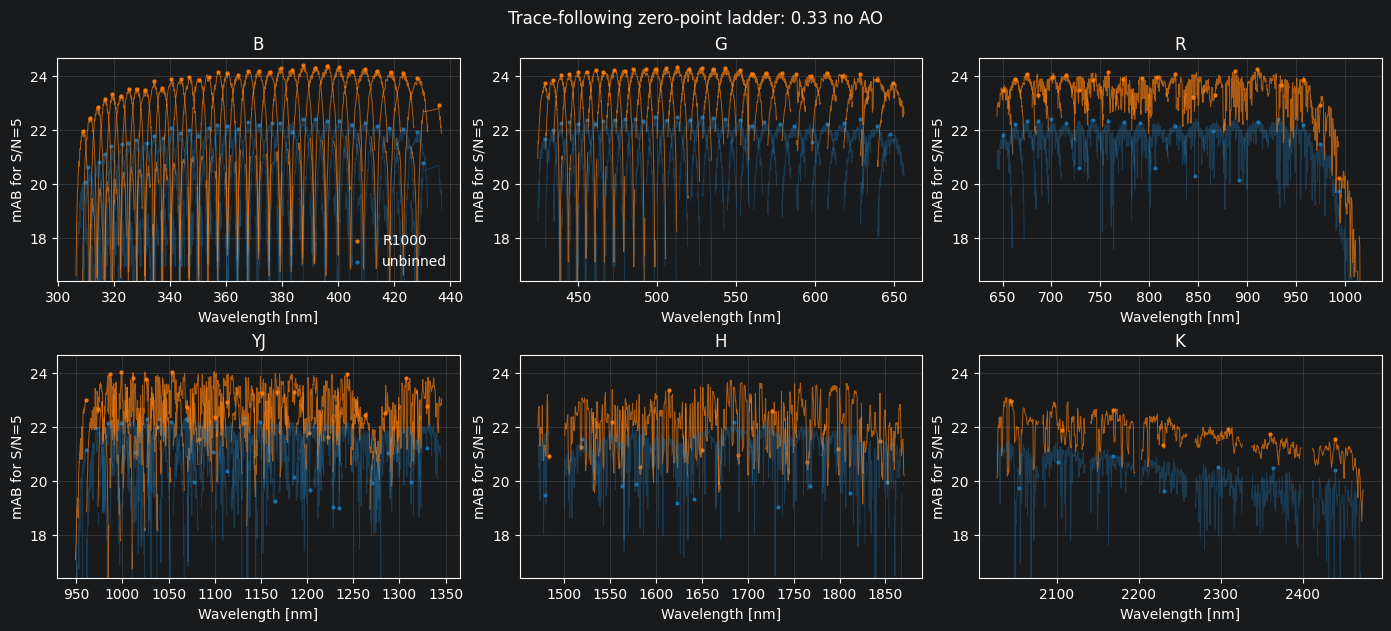

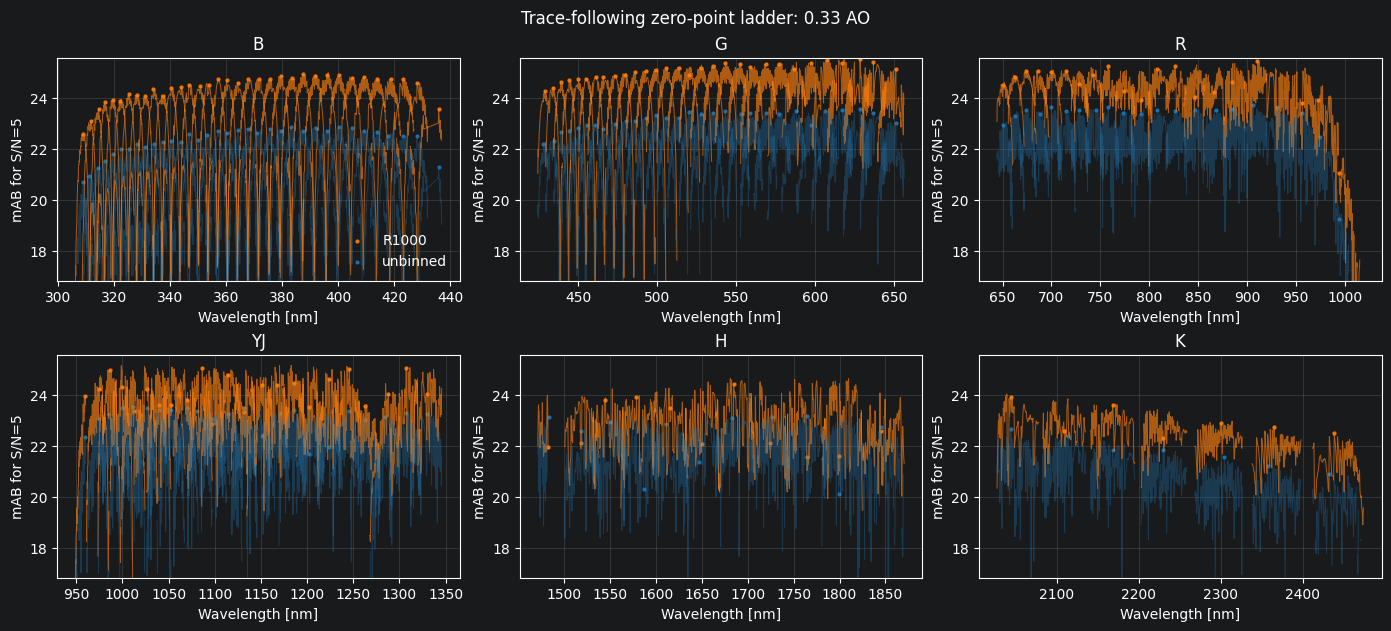

In [60]:
def make_science_case_cmd(*, slit_arcsec=0.33):
    case_cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
    case_cmd["!OBS.airmass"] = cmd_value("!OBS.airmass")
    case_cmd["!OBS.seeing"] = cmd_value("!OBS.seeing")
    case_cmd["!OBS.brightness"] = cmd_value("!OBS.brightness")
    case_cmd["!OBS.pupil_angle"] = cmd_value("!OBS.pupil_angle")
    set_channel_exposure(case_cmd, dit=1800, ndit=2)
    case_cmd["!INST.vis_curr_slit"] = slit_arcsec
    case_cmd["!INST.nir_curr_slit"] = slit_arcsec
    case_cmd["!SIM.spectral.spectral_resolution"] = cmd_value("!SIM.spectral.spectral_resolution")
    case_cmd["!INST.include_diffuse_emmisivity"] = cmd_value("!INST.include_diffuse_emmisivity")
    warning_prevent_sync_alt_ra_dec(case_cmd)
    return case_cmd


def psf_fwhm_arcsec(values):
    quantity = u.Quantity(values)
    if quantity.unit == u.dimensionless_unscaled:
        return quantity.value * u.arcsec
    return quantity.to(u.arcsec)


def set_train_ao_state(train, enabled):
    psf = get_effect(train, "seeing_psf", active_only=False)
    psf.meta["enable_ao"] = bool(enabled)
    if enabled:
        if bool(psf.meta.get("is_absolute", True)):
            psf.fwhm = lambda wavelengths, ao_scale=psf.ao_scale: psf_fwhm_arcsec(ao_scale(wavelengths))
        else:
            natural_fwhm = psf.get_fwhm_interp()
            psf.fwhm = lambda wavelengths, natural_fwhm=natural_fwhm, ao_scale=psf.ao_scale: (natural_fwhm(wavelengths) * ao_scale(wavelengths)).to(u.arcsec)
    else:
        natural_fwhm = psf.get_fwhm_interp()
        psf.fwhm = lambda wavelengths, natural_fwhm=natural_fwhm: psf_fwhm_arcsec(natural_fwhm(wavelengths))
    return psf


def observe_train_readout(train, source=None):
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    with disable_scopesim_progress_bars(hide_scopesim_progress):
        if source is None:
            train.observe()
        else:
            train.observe(source)
        hdul = train.readout()
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    return hdul


narrow_slit_arcsec = 0.33
narrow_background_cmd = make_science_case_cmd(slit_arcsec=narrow_slit_arcsec)
narrow_background_train = sim.OpticalTrain(narrow_background_cmd)
narrow_detector_budget = detector_background_budget_table(narrow_background_train)
narrow_empty_hdul = observe_train_readout(narrow_background_train, None)


def run_smallest_slit_ao_case(label, *, ao_enabled, empty_hdul, budget):
    case_cmd = make_science_case_cmd(slit_arcsec=narrow_slit_arcsec)
    train = sim.OpticalTrain(case_cmd)
    set_train_ao_state(train, ao_enabled)
    trace_res = trace_resolution_diagnostic_table(train, samples_per_trace=96)
    trace_summary = trace_resolution_summary_table(trace_res)
    src_hdul = observe_train_readout(train, source_to_observe)
    _signals, _background, case_snr_images = snr_images_from_readouts(src_hdul, empty_hdul, budget, readout_titles)
    by_order = trace_peak_resel_snr_by_order(trace_res, case_snr_images, readout_titles)
    summary, display_rows = trace_peak_resel_snr_summary(by_order, readout_titles)
    psf_by_channel = {str(row["channel"]): float(row["seeing_fwhm_median_arcsec"]) for row in trace_summary}
    summary["case"] = label
    summary["psf_fwhm_arcsec"] = [psf_by_channel.get(str(channel), np.nan) for channel in summary["channel"]]
    for row in display_rows:
        row["case"] = label
        row["psf_fwhm_arcsec"] = psf_by_channel.get(str(row["channel"]), np.nan)
    zp_ladder = trace_zero_point_ladder_table(
        src_hdul,
        empty_hdul,
        budget,
        trace_res,
        readout_titles,
        input_abmag=zero_point_input_abmag,
        case_label=label,
    )
    zp_order_peaks = representative_zero_point_order_table(zp_ladder)
    return {
        "label": label,
        "train": train,
        "trace_summary": trace_summary,
        "snr": summary,
        "snr_display": display_rows,
        "snr_by_order": by_order,
        "zero_point_ladder": zp_ladder,
        "zero_point_order_peaks": zp_order_peaks,
    }


ao_cases = [
    run_smallest_slit_ao_case("0.33 no AO", ao_enabled=False, empty_hdul=narrow_empty_hdul, budget=narrow_detector_budget),
    run_smallest_slit_ao_case("0.33 AO", ao_enabled=True, empty_hdul=narrow_empty_hdul, budget=narrow_detector_budget),
]

ao_snr_rows = [row for case in ao_cases for row in case["snr_display"]]
display_frame(
    ao_snr_rows,
    columns=["case", "channel", "psf_fwhm_arcsec", "orders", "wave [nm]", "pix S/N", "S/N", "p90 pix S/N", "eff pix"],
    formats={"psf_fwhm_arcsec": "{:.3f}"},
)

ao_zero_point_ladder = Table(rows=[row for case in ao_cases for row in case["zero_point_ladder"]])
ao_zero_point_order_peaks = Table(rows=[row for case in ao_cases for row in case["zero_point_order_peaks"]])
ao_zero_point_summary_display = zero_point_summary_display_table(ao_zero_point_order_peaks, readout_titles)
print(f"Narrow-slit trace-following zero-point estimate from m_AB={zero_point_input_abmag:.1f}; target S/N={ZERO_POINT_TARGET_SNR:.1f}")
display_frame(
    ao_zero_point_summary_display,
    formats={"med_S/N": "{:.1f}", "med_mAB5": "{:.1f}"},
)

for case in ao_cases:
    fig, axes = plot_zero_point_ladder(
        ao_zero_point_ladder,
        ao_zero_point_order_peaks,
        case_label=case["label"],
        titles=readout_titles,
    )
    display(fig)
    plt.close(fig)


In [61]:
def zero_point_pixel_count_summary(ladder_table, *, titles=readout_titles, modes=("unbinned", "R1000")):
    rows = []
    case_values = np.asarray(ladder_table["case"], dtype=str)
    channel_values = np.asarray(ladder_table["channel"], dtype=str)
    mode_values = np.asarray(ladder_table["mode"], dtype=str)

    for case in list(dict.fromkeys(case_values)):
        for channel in titles:
            for mode in modes:
                mask = (
                    (case_values == case)
                    & (channel_values == channel)
                    & (mode_values == mode)
                )
                if not np.any(mask):
                    continue

                group = ladder_table[mask]
                n_pix = np.asarray(group["n_pix"], dtype=float)
                spec_pix = np.asarray(group["spectral_width_pix"], dtype=float)
                spat_pix = np.asarray(group["spatial_width_pix"], dtype=float)

                rows.append({
                    "case": case,
                    "ch": channel,
                    "mode": mode,
                    "N": len(group),
                    "pix/bin": f"{np.nanmin(n_pix):.0f}-{np.nanmax(n_pix):.0f}",
                    "med_pix/bin": float(np.nanmedian(n_pix)),
                    "spec_pix": f"{np.nanmin(spec_pix):.1f}-{np.nanmax(spec_pix):.1f}",
                    "med_spec_pix": float(np.nanmedian(spec_pix)),
                    "spat_pix": f"{np.nanmin(spat_pix):.1f}-{np.nanmax(spat_pix):.1f}",
                    "med_spat_pix": float(np.nanmedian(spat_pix)),
                })
    return rows


display_frame(
    zero_point_pixel_count_summary(ao_zero_point_ladder),
    formats={
        "med_pix/bin": "{:.1f}",
        "med_spec_pix": "{:.1f}",
        "med_spat_pix": "{:.1f}",
    },
)

case,ch,mode,N,pix/bin,med_pix/bin,spec_pix,med_spec_pix,spat_pix,med_spat_pix
0.33 no AO,B,unbinned,3247,15-15,15.0,2.1-2.1,2.1,4.5-4.9,4.7
0.33 no AO,B,R1000,3247,340-490,400.0,67.4-97.6,79.3,4.5-4.9,4.7
0.33 no AO,G,unbinned,2782,15-15,15.0,2.1-2.1,2.1,4.2-4.6,4.4
0.33 no AO,G,R1000,2782,345-485,400.0,68.1-96.4,79.2,4.2-4.6,4.4
0.33 no AO,R,unbinned,1974,12-15,15.0,2.1-2.1,2.1,3.8-4.2,4.0
0.33 no AO,R,R1000,1974,276-485,370.0,68.0-96.3,79.2,3.8-4.2,4.0
0.33 no AO,YJ,unbinned,2112,12-12,12.0,2.1-2.1,2.1,3.6-3.9,3.8
0.33 no AO,YJ,R1000,2112,280-376,316.0,69.4-93.3,78.6,3.6-3.9,3.8
0.33 no AO,H,unbinned,976,12-12,12.0,2.1-2.1,2.1,3.4-3.6,3.5
0.33 no AO,H,R1000,976,280-376,316.0,69.2-93.9,78.5,3.4-3.6,3.5


## What To Report

For a presentation or release note, the key tables are the run card, throughput summary, slit-loss-at-current-slit summary, emissivity summary, detector budget, explicit source/sky BoE count scale, source-minus-empty delta summary, trace-peak S/N table, trace-following zero-point summary, AO comparison, and the scenario-delta summaries. The plots should answer whether the traces are present, whether sky lines and diffuse backgrounds move the expected pixels, whether telescope/instrument emissivity rates are in the right ballpark, whether the source/background/S/N cuts are mutually plausible, and whether the zero-point estimate is driven by believable order-center peaks rather than a fixed detector-column cut.
